# GLOBAL HIV TREND ANALYSIS AND NEONATAL AND CHILDREN UNDER THE AGE OF FIVE DEATHS IN EASTERN AFRICA

### Overview

HIV continues to be a major public health issue in Africa, with a high number of people living with the virus, especially in sub-Saharan regions. While prevention and treatment efforts have improved, HIV is a lifelong condition, making it crucial to track data on the affected. This data helps us identify infection trends, prepare healthcare services to accommodate these patients, and address challenges like stigma and inequality.  Beyond health, HIV also impacts jobs, healthcare costs, and poverty levels, making it important to use data to create targeted interventions. By analyzing this information, governments and organizations can better allocate resources and create policies to help reduce transmission and improve the quality of life for those affected.

## Task 1.

### 1.0 Objectives

1.To create a visualization that shows the trend of HIV cases in the countries that contribute to 75% of the global burden 

2.To generate a visualization that displays the trend of HIV cases in the countries contributing to 75% of the burden within each WHO region.

3.To analyze the relationship between people living with HIV and multidimensional poverty.

### 2.0 Data Understanding

The data for this analysis is obtained from the World Health Organization (WHO) Global Observatory, containing data on people living with HIV at the country level from 2000 to 2023. 

In [1]:
#importing the relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import statsmodels.formula.api as smf
import re
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder
import geopandas as gpd
import warnings
warnings.filterwarnings("ignore")
%load_ext autoreload
%autoreload 2

In [2]:
#reading the data into the notebook.
HIV_data=pd.read_csv("HIV data 2000-2023.csv",encoding="latin1")
HIV_data.head(3)

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Value
0,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2023,320 000 [280 000 - 380 000]
1,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2022,320 000 [280 000 - 380 000]
2,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2021,320 000 [280 000 - 380 000]


In [3]:
#checking for the shape of the dataset
HIV_data.shape

(1552, 11)

In [4]:
#checking for the columns
list(HIV_data.columns)

['IndicatorCode',
 'Indicator',
 'ValueType',
 'ParentLocationCode',
 'ParentLocation',
 'Location type',
 'SpatialDimValueCode',
 'Location',
 'Period type',
 'Period',
 'Value']

The global HIV dataset contains 1552 observations and 11 variables.The variables are ['IndicatorCode',
 'Indicator',
 'ValueType',
 'ParentLocationCode',
 'ParentLocation',
 'Location type',
 'SpatialDimValueCode',
 'Location',
 'Period type',
 'Period',
 'Value']

In [5]:
#loading the multidimensional poverty excel file
poverty_data=pd.read_excel("multidimensional_poverty.xlsx")
poverty_data.head(3)

,"Individuals in households deprived in each indicator, 110 economies, circa year 2021 (2018-2023)\nDate: October 2024",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,Region,Country code,Economy,Reporting year,Survey name,Survey year,Survey coverage,Welfare type,Survey comparability,Deprivation rate (share of population),NaN,NaN,NaN,NaN,NaN,Multidimensional poverty headcount ratio (%)
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monetary (%),Educational attainment (%),Educational enrollment (%),Electricity (%),Sanitation (%),Drinking water (%),NaN
2,SSA,AGO,Angola,2018,IDREA,2018,N,c,2,31.122,29.7534,27.4431,52.6395,53.6375,32.1065,47.2036


The multidimensional poverty dataset contains 112 rows and 16 columns.The columns are in three dimensions and require flattening for easier understaning and visualization.

### 3.0 Data Exploration and cleaning

In [6]:
#checking for general information about the HIV dataset
HIV_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   IndicatorCode        1552 non-null   object
 1   Indicator            1552 non-null   object
 2   ValueType            1552 non-null   object
 3   ParentLocationCode   1552 non-null   object
 4   ParentLocation       1552 non-null   object
 5   Location type        1552 non-null   object
 6   SpatialDimValueCode  1552 non-null   object
 7   Location             1552 non-null   object
 8   Period type          1552 non-null   object
 9   Period               1552 non-null   int64 
 10  Value                1552 non-null   object
dtypes: int64(1), object(10)
memory usage: 133.5+ KB


From the above observation,there are no missing values in the dataset.There are 10 columns with object data type and one with integer data type.Worth noting is that some missing values may be replaced by placeholders such as "NAN".

In [7]:
#checking for missing values
HIV_data.isna().sum()

IndicatorCode          0
Indicator              0
ValueType              0
ParentLocationCode     0
ParentLocation         0
Location type          0
SpatialDimValueCode    0
Location               0
Period type            0
Period                 0
Value                  0
dtype: int64

This confirms that there are no missing values in the dataset

In [8]:
#checking for duplicated values in the dataset
HIV_data.duplicated().sum()

0

There are no duplicated values in the data.

In [9]:
#checking for high and low cardinality columns
HIV_data.nunique()

IndicatorCode            1
Indicator                1
ValueType                1
ParentLocationCode       6
ParentLocation           6
Location type            1
SpatialDimValueCode    194
Location               194
Period type              1
Period                   8
Value                  895
dtype: int64

In [10]:
#dropping the columns with low cardinality
low_cardinality_cols=["IndicatorCode","Indicator","ValueType","Location type","Period type"]
HIV_data.drop(columns=low_cardinality_cols,inplace=True)

low cardinality columns may not contain relevant information.For instance the indicator code column contains only one value.Asuuming thata the value at the end of the code indicates a HIV positive individual,then it means all the observations are for people living with the virus and the column would be irrelevant same to indicator,valueType,and period_type.

In [11]:
HIV_data.head(3)

,ParentLocationCode,ParentLocation,SpatialDimValueCode,Location,Period,Value
0,AFR,Africa,AGO,Angola,2023,320 000 [280 000 - 380 000]
1,AFR,Africa,AGO,Angola,2022,320 000 [280 000 - 380 000]
2,AFR,Africa,AGO,Angola,2021,320 000 [280 000 - 380 000]


In [12]:
print(f"This has reduced the columns to {len(HIV_data.columns)}")

This has reduced the columns to 6


In [13]:
#checking for individual columns value counts
HIV_data["ParentLocationCode"].value_counts(normalize=True)

EUR     0.273196
AFR     0.242268
AMR     0.180412
WPR     0.139175
EMR     0.108247
SEAR    0.056701
Name: ParentLocationCode, dtype: float64

In [14]:
HIV_data["ParentLocation"].value_counts(normalize=True)

Europe                   0.273196
Africa                   0.242268
Americas                 0.180412
Western Pacific          0.139175
Eastern Mediterranean    0.108247
South-East Asia          0.056701
Name: ParentLocation, dtype: float64

The columns parentlocationcode and parent location contain the same information about a region and also same value count.The parent location code column is dropped and Parent Location retained.Europe leads in the number of countries observed at 27%,followed by Africa at 24%, Americas at 18%,Western Pacific at 13%,Eastern Mediterranean at 10% and lastly South East Asia at 5%.

In [15]:
HIV_data.drop(columns=["ParentLocationCode"],inplace=True)

In [16]:
HIV_data.head(3)

,ParentLocation,SpatialDimValueCode,Location,Period,Value
0,Africa,AGO,Angola,2023,320 000 [280 000 - 380 000]
1,Africa,AGO,Angola,2022,320 000 [280 000 - 380 000]
2,Africa,AGO,Angola,2021,320 000 [280 000 - 380 000]


In [17]:
#checking for the value column
HIV_data["Value"].value_counts(normalize=True)

No data                        0.253866
<500 [<500 - <500]             0.016753
<200 [<100 - <200]             0.005799
<100 [<100 - <100]             0.005155
140 000 [120 000 - 160 000]    0.005155
                                 ...   
41 000 [36 000 - 47 000]       0.000644
2200 [2000 - 2400]             0.000644
430 000 [380 000 - 490 000]    0.000644
1100 [970 - 1300]              0.000644
860 [730 - 950]                0.000644
Name: Value, Length: 895, dtype: float64

In [18]:
#rows with no data account for approximately 25% of the Value column.For accuracy,the rows are dropped.
mask=HIV_data["Value"]!="No data"
HIV_data=HIV_data[mask]
HIV_data.head(3)

,ParentLocation,SpatialDimValueCode,Location,Period,Value
0,Africa,AGO,Angola,2023,320 000 [280 000 - 380 000]
1,Africa,AGO,Angola,2022,320 000 [280 000 - 380 000]
2,Africa,AGO,Angola,2021,320 000 [280 000 - 380 000]


In [19]:
HIV_data['Value'].value_counts(normalize=True)

<500 [<500 - <500]             0.022453
<200 [<100 - <200]             0.007772
<100 [<100 - <100]             0.006908
140 000 [120 000 - 160 000]    0.006908
17 000 [15 000 - 19 000]       0.006045
                                 ...   
41 000 [36 000 - 47 000]       0.000864
2200 [2000 - 2400]             0.000864
430 000 [380 000 - 490 000]    0.000864
1100 [970 - 1300]              0.000864
860 [730 - 950]                0.000864
Name: Value, Length: 894, dtype: float64

In [20]:
#cleaning the vaalue column
HIV_data[['Main_Value', 'Lower', 'Upper']] = (
    HIV_data['Value']
    .str.extract(r'([\d ]+)\s*\[([\d ]+)\s*-\s*([\d ]+)\]')
    .apply(lambda x: x.str.replace(' ', '').astype(float))
)

In [21]:
HIV_data

,ParentLocation,SpatialDimValueCode,Location,Period,Value,Main_Value,Lower,Upper
0,Africa,AGO,Angola,2023,320 000 [280 000 - 380 000],320000.0,280000.0,380000.0
1,Africa,AGO,Angola,2022,320 000 [280 000 - 380 000],320000.0,280000.0,380000.0
2,Africa,AGO,Angola,2021,320 000 [280 000 - 380 000],320000.0,280000.0,380000.0
3,Africa,AGO,Angola,2020,320 000 [280 000 - 370 000],320000.0,280000.0,370000.0
4,Africa,AGO,Angola,2015,300 000 [260 000 - 350 000],300000.0,260000.0,350000.0
...,...,...,...,...,...,...,...,...
1531,Western Pacific,VNM,Viet Nam,2020,250 000 [230 000 - 270 000],250000.0,230000.0,270000.0
1532,Western Pacific,VNM,Viet Nam,2015,240 000 [210 000 - 260 000],240000.0,210000.0,260000.0
1533,Western Pacific,VNM,Viet Nam,2010,210 000 [190 000 - 230 000],210000.0,190000.0,230000.0
1534,Western Pacific,VNM,Viet Nam,2005,180 000 [150 000 - 200 000],180000.0,150000.0,200000.0


In [22]:
#dropping the columns value,lower and upper
HIV_data.drop(columns=["Value","Lower","Upper"],inplace=True)

In [23]:
#renaming the min value column approxNoOfinfections
HIV_data = HIV_data.rename(columns={'Main_Value': 'ApproxNoOfInfections'})

In [24]:
#cleaning the multidimensional poverty dataset
# reloading the dataset,removing the header 
poverty_data=pd.read_excel("multidimensional_poverty.xlsx",header=None)
poverty_data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,Individuals in households deprived in each ind...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Region,Country code,Economy,Reporting year,Survey name,Survey year,Survey coverage,Welfare type,Survey comparability,Deprivation rate (share of population),NaN,NaN,NaN,NaN,NaN,Multidimensional poverty headcount ratio (%)
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monetary (%),Educational attainment (%),Educational enrollment (%),Electricity (%),Sanitation (%),Drinking water (%),NaN
3,SSA,AGO,Angola,2018,IDREA,2018,N,c,2,31.122,29.7534,27.4431,52.6395,53.6375,32.1065,47.2036
4,ECA,ALB,Albania,2012,HBS,2018,N,c,1,0.048107,0.19238,-,0.06025,6.57977,9.59497,0.293161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,ECA,UZB,Uzbekistan,2022,HBS,2022,N,c,1,2.25309,0,-,0.12747,21.7869,10.6937,2.25309
109,EAP,VNM,Viet Nam,2010,VHLSS,2022,N,c,2,0.963795,3.38482,1.84141,0.0797325,4.1329,1.96813,1.26618
110,EAP,VUT,Vanuatu,2010,NSDP,2019,N,c,0,9.96333,25.7231,13.4043,26.9942,42.9701,11.8136,19.8922
111,SSA,ZMB,Zambia,2010,LCMS-VIII,2022,N,c,4,64.342,16.2678,23.3984,45.1351,53.5051,26.8492,66.5061


In [25]:
#creating new column headers for the data 
columns= [
    'Region', 'Country_Code', 'Country', 'Year', 
    'Survey_Name', 'Survey_Year', 'Coverage', 
    'Welfare_type', 'Survey_Comparability', 'Poverty_Rate',
    'Education_Attainment', 'Education_Enrollment',
    'Electricity_Access', 'Sanitation_Access',
    'Drinking_Water_Access', 'PovertyHeadCountRatio'
]
poverty_data.columns=columns

In [26]:
poverty_data.head()

,Region,Country_Code,Country,Year,Survey_Name,Survey_Year,Coverage,Welfare_type,Survey_Comparability,Poverty_Rate,Education_Attainment,Education_Enrollment,Electricity_Access,Sanitation_Access,Drinking_Water_Access,PovertyHeadCountRatio
0,Individuals in households deprived in each ind...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Region,Country code,Economy,Reporting year,Survey name,Survey year,Survey coverage,Welfare type,Survey comparability,Deprivation rate (share of population),NaN,NaN,NaN,NaN,NaN,Multidimensional poverty headcount ratio (%)
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monetary (%),Educational attainment (%),Educational enrollment (%),Electricity (%),Sanitation (%),Drinking water (%),NaN
3,SSA,AGO,Angola,2018,IDREA,2018,N,c,2,31.122,29.7534,27.4431,52.6395,53.6375,32.1065,47.2036
4,ECA,ALB,Albania,2012,HBS,2018,N,c,1,0.048107,0.19238,-,0.06025,6.57977,9.59497,0.293161


In [27]:
poverty_data= poverty_data.iloc[3:].reset_index(drop=True)
poverty_data

,Region,Country_Code,Country,Year,Survey_Name,Survey_Year,Coverage,Welfare_type,Survey_Comparability,Poverty_Rate,Education_Attainment,Education_Enrollment,Electricity_Access,Sanitation_Access,Drinking_Water_Access,PovertyHeadCountRatio
0,SSA,AGO,Angola,2018,IDREA,2018,N,c,2,31.122,29.7534,27.4431,52.6395,53.6375,32.1065,47.2036
1,ECA,ALB,Albania,2012,HBS,2018,N,c,1,0.048107,0.19238,-,0.06025,6.57977,9.59497,0.293161
2,LAC,ARG,Argentina,2010,EPHC-S2,2021,U,i,3,0.894218,1.08532,0.731351,0,0.257453,0.364048,0.906573
3,ECA,ARM,Armenia,2010,ILCS,2021,N,c,1,0.523521,0,1.793,0,0.397725,0.660082,0.523521
4,EAP,AUS,Australia,2010,SIH-LIS,2018,N,I,3,0.51688,1.71188,-,0,0,-,2.21577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,ECA,UZB,Uzbekistan,2022,HBS,2022,N,c,1,2.25309,0,-,0.12747,21.7869,10.6937,2.25309
106,EAP,VNM,Viet Nam,2010,VHLSS,2022,N,c,2,0.963795,3.38482,1.84141,0.0797325,4.1329,1.96813,1.26618
107,EAP,VUT,Vanuatu,2010,NSDP,2019,N,c,0,9.96333,25.7231,13.4043,26.9942,42.9701,11.8136,19.8922
108,SSA,ZMB,Zambia,2010,LCMS-VIII,2022,N,c,4,64.342,16.2678,23.3984,45.1351,53.5051,26.8492,66.5061


In [28]:
#checking for general information about the dataset
poverty_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Region                 110 non-null    object
 1   Country_Code           110 non-null    object
 2   Country                110 non-null    object
 3   Year                   110 non-null    object
 4   Survey_Name            110 non-null    object
 5   Survey_Year            110 non-null    object
 6   Coverage               110 non-null    object
 7   Welfare_type           110 non-null    object
 8   Survey_Comparability   110 non-null    object
 9   Poverty_Rate           110 non-null    object
 10  Education_Attainment   110 non-null    object
 11  Education_Enrollment   110 non-null    object
 12  Electricity_Access     110 non-null    object
 13  Sanitation_Access      110 non-null    object
 14  Drinking_Water_Access  110 non-null    object
 15  PovertyHeadCountRatio  

All the datasets are objects yet from the observation,we can see date time and numerical data types.

In [29]:
# Convert numeric columns
numeric_cols = [
    'Year', 'Survey_Year', 'Survey_Comparability',
    'Poverty_Rate', 'Education_Attainment',
    'Education_Enrollment', 'Electricity_Access',
    'Sanitation_Access', 'Drinking_Water_Access',"PovertyHeadCountRatio"
]

for col in numeric_cols:
    poverty_data[col] = pd.to_numeric(poverty_data[col], errors='coerce')


In [30]:
#checking for percentage missing values
cols_with_missing_vals=poverty_data.isna().mean()
cols_with_missing_vals

Region                   0.000000
Country_Code             0.000000
Country                  0.000000
Year                     0.000000
Survey_Name              0.000000
Survey_Year              0.000000
Coverage                 0.000000
Welfare_type             0.000000
Survey_Comparability     0.000000
Poverty_Rate             0.000000
Education_Attainment     0.009091
Education_Enrollment     0.327273
Electricity_Access       0.009091
Sanitation_Access        0.227273
Drinking_Water_Access    0.081818
PovertyHeadCountRatio    0.000000
dtype: float64

In [31]:
print(f"There are  missing values in the dataset.The columns with missing values are:  {cols_with_missing_vals[cols_with_missing_vals!=0]}")

There are  missing values in the dataset.The columns with missing values are:  Education_Attainment     0.009091
Education_Enrollment     0.327273
Electricity_Access       0.009091
Sanitation_Access        0.227273
Drinking_Water_Access    0.081818
dtype: float64


In [32]:
missing_cols = ["Education_Attainment", "Education_Enrollment", 
               "Electricity_Access", "Sanitation_Access", 
               "Drinking_Water_Access"]
#imputing the missing values with the median,median is not affected by outliers
for col in missing_cols:
    poverty_data[col] = poverty_data[col].fillna(poverty_data[col].median())

In [33]:
poverty_data.isna().sum()

Region                   0
Country_Code             0
Country                  0
Year                     0
Survey_Name              0
Survey_Year              0
Coverage                 0
Welfare_type             0
Survey_Comparability     0
Poverty_Rate             0
Education_Attainment     0
Education_Enrollment     0
Electricity_Access       0
Sanitation_Access        0
Drinking_Water_Access    0
PovertyHeadCountRatio    0
dtype: int64

In [34]:
#checking for duplicates
poverty_data.duplicated().sum()

0

There are also no duplicated values in the dataset.

In [35]:
#checking for cardinality
poverty_data.select_dtypes(include="object").nunique()

Region            7
Country_Code    110
Country         110
Survey_Name      57
Coverage          2
Welfare_type      3
dtype: int64

The Welfare_type and Coverage have low cardinality ie 3 and 2 respectively.They however cannot be dropped as they can give us more information about the different classifications and help us  understand the distribution of the affected individuals based on their coverage or  Welfare type. 

In [36]:
#converting to datetime
poverty_data["Year"] = pd.to_datetime( poverty_data['Year'], format='%Y',  errors='coerce').dt.year
poverty_data["Survey_Year"] = pd.to_datetime( poverty_data["Survey_Year"], format='%Y',  errors='coerce').dt.year

In [37]:
poverty_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Region                 110 non-null    object 
 1   Country_Code           110 non-null    object 
 2   Country                110 non-null    object 
 3   Year                   110 non-null    int64  
 4   Survey_Name            110 non-null    object 
 5   Survey_Year            110 non-null    int64  
 6   Coverage               110 non-null    object 
 7   Welfare_type           110 non-null    object 
 8   Survey_Comparability   110 non-null    int64  
 9   Poverty_Rate           110 non-null    float64
 10  Education_Attainment   110 non-null    float64
 11  Education_Enrollment   110 non-null    float64
 12  Electricity_Access     110 non-null    float64
 13  Sanitation_Access      110 non-null    float64
 14  Drinking_Water_Access  110 non-null    float64
 15  Povert

### 4.0 Data Analysis and Visualization

#### 4.0.1.Visualization that shows the trend of HIV cases in the countries that contribute to 75% of the global burden

In [38]:
#for this analysis we will use the HIV_data.dropping any null values.
HIV_data.dropna(inplace=True)
HIV_data

,ParentLocation,SpatialDimValueCode,Location,Period,ApproxNoOfInfections
0,Africa,AGO,Angola,2023,320000.0
1,Africa,AGO,Angola,2022,320000.0
2,Africa,AGO,Angola,2021,320000.0
3,Africa,AGO,Angola,2020,320000.0
4,Africa,AGO,Angola,2015,300000.0
...,...,...,...,...,...
1531,Western Pacific,VNM,Viet Nam,2020,250000.0
1532,Western Pacific,VNM,Viet Nam,2015,240000.0
1533,Western Pacific,VNM,Viet Nam,2010,210000.0
1534,Western Pacific,VNM,Viet Nam,2005,180000.0


In [39]:
#grouping infections by country
infections_by_country=HIV_data.groupby('Location')['ApproxNoOfInfections'].mean().reset_index(name='Average_Cases')
infections_by_country.sort_values(by="Average_Cases",ascending=False).head(10)

,Location,Average_Cases
119,South Africa,6425000.0
58,India,2500000.0
89,Mozambique,1893750.0
97,Nigeria,1875000.0
68,Kenya,1500000.0
135,United Republic of Tanzania,1450000.0
142,Zimbabwe,1362500.0
132,Uganda,1312500.0
141,Zambia,1111250.0
80,Malawi,970000.0


South Africa leads in the number of people living with HIV and AIDS followed by India,Mozambique,Nigeria,Kenya,and United Republic of Tanzania.This could be due to the high prevalance rates in these regions.India has a high population,a reason for the high number of infections.

In [40]:
infections_by_country.dropna(inplace=True)

In [41]:
infections_by_country["Average_Cases"].sum()

30731642.476190478

In [42]:
#creating a column global contribution
infections_by_country["Contribution"]=infections_by_country["Average_Cases"]/infections_by_country["Average_Cases"].sum()*100
#countries with more than 75% global contribution
more_than_75=infections_by_country.sort_values(by="Contribution",ascending=False).head(15)
more_than_75

,Location,Average_Cases,Contribution
119,South Africa,6425000.0,20.906790
58,India,2500000.0,8.134938
89,Mozambique,1893750.0,6.162215
97,Nigeria,1875000.0,6.101203
68,Kenya,1500000.0,4.880963
135,United Republic of Tanzania,1450000.0,4.718264
142,Zimbabwe,1362500.0,4.433541
132,Uganda,1312500.0,4.270842
141,Zambia,1111250.0,3.615980
80,Malawi,970000.0,3.156356


In [43]:
# checking for percentage contribution for the top 15 countries to ascertain if the contribute more than 75% global HIV/AIDS infections
infections_by_country.sort_values(by="Contribution",ascending=False).dropna().head(15).sum()

Location         South AfricaIndiaMozambiqueNigeriaKenyaUnited ...
Average_Cases                                            2.354e+07
Contribution                                               76.5986
dtype: object

The top 15 countries contribute more than 75% of global HIV related cases led by south Africa contributing about 21% .Other countries in the top 5 are,India at 8%,mozambique 6%,Nigeria 6% and Kenya 4%.

In [44]:
top_15_countries=more_than_75["Location"].reset_index(drop=True).to_list()
print(f"The countries with more than 75% global distributions are:{top_15_countries}")

The countries with more than 75% global distributions are:['South Africa', 'India', 'Mozambique', 'Nigeria', 'Kenya', 'United Republic of Tanzania', 'Zimbabwe', 'Uganda', 'Zambia', 'Malawi', 'Brazil', 'Thailand', 'Ethiopia', 'Democratic Republic of the Congo', "Cote d'Ivoire"]


In [45]:
#filtering the data to select only the top 15 countries
mask=HIV_data["Location"].isin(top_15_countries)
trend_data=HIV_data[mask]
trend_data.head()

,ParentLocation,SpatialDimValueCode,Location,Period,ApproxNoOfInfections
48,Africa,CIV,Cote d'Ivoire,2023,420000.0
49,Africa,CIV,Cote d'Ivoire,2022,430000.0
50,Africa,CIV,Cote d'Ivoire,2021,430000.0
51,Africa,CIV,Cote d'Ivoire,2020,440000.0
52,Africa,CIV,Cote d'Ivoire,2015,460000.0


In [46]:
#Checking the distribution based 
trend_data["ParentLocation"].value_counts(normalize=True)

Africa             0.849558
South-East Asia    0.079646
Americas           0.070796
Name: ParentLocation, dtype: float64

Africa accounts for about 85% of the 75% global HIV cases,folowed by South-East Asia and Americas at about 8% and 7% each.

In [47]:
#Visualization of the trend.
# Creating the  line plot
fig = px.line(
    trend_data,
    x='Period',
    y='ApproxNoOfInfections',
    color='Location',
    title='Trend of HIV Cases in Countries Contributing >75% of Global Burden (2000–2023)',
    hover_data=['Location', 'ParentLocation']
)
#setting the x -axis,y-axis and legend labels
fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Number of HIV Cases',
    legend_title='Country',
)
fig.show()

From the above plot,it is worth noting that HIV related cases have steadily increased in South Africa and Mozambique.It is however difficult to communicate the visualization for the other countries and plotting the trend for individual countries would improve the visualization.

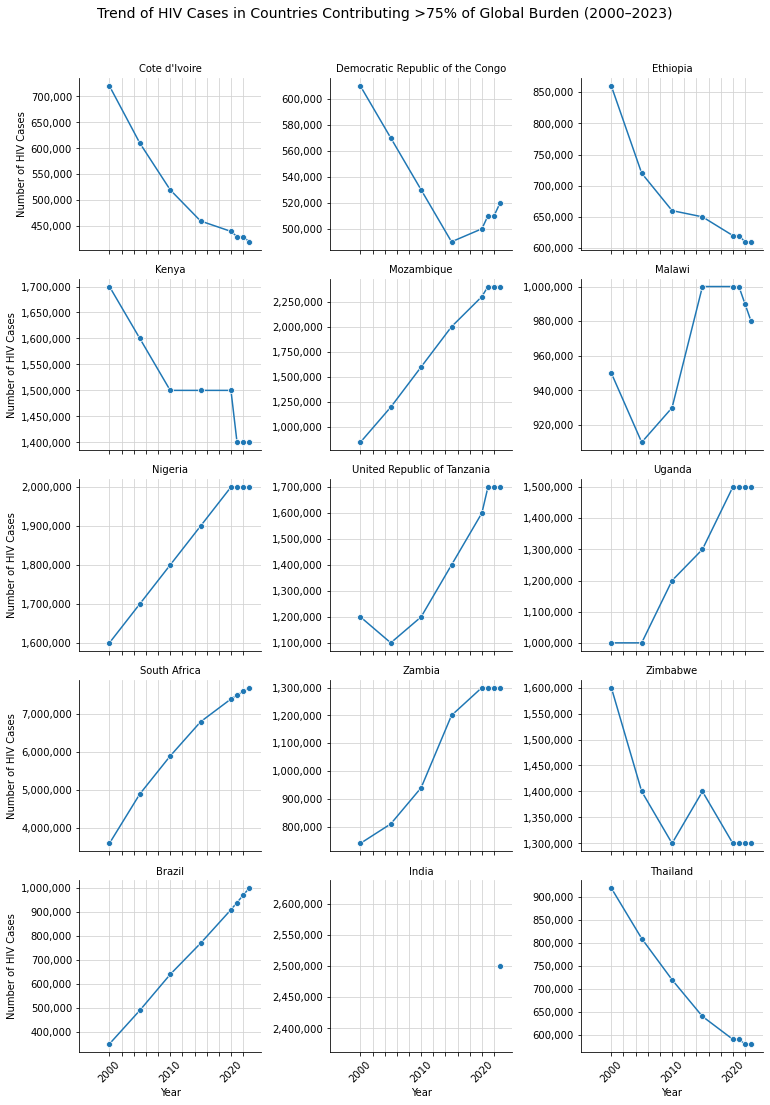

In [48]:
# Creating a FacetGrid
g = sns.FacetGrid(
    trend_data,
    col='Location',
    col_wrap=3, 
    height=3,    
    aspect=1.2,  
    sharey=False  
)
# Plot lines for each country
g.map(sns.lineplot, 'Period', 'ApproxNoOfInfections', marker='o')
g.set_titles('{col_name}', size=10)  # Use country name as subplot title
g.set_axis_labels('Year', 'Number of HIV Cases')
g.set_xticklabels(rotation=45)
# Add grid and format y-axis
for ax in g.axes.flat:
    ax.grid(True, color='lightgray')
    ax.set_xticks(range(2000, 2024, 2))  # X-ticks every 2 years
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
# Adding main title
g.fig.suptitle('Trend of HIV Cases in Countries Contributing >75% of Global Burden (2000–2023)', y=1.02, fontsize=14)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

In [49]:
HIV_India=HIV_data[HIV_data['Location']=="India"]
HIV_India

,ParentLocation,SpatialDimValueCode,Location,Period,ApproxNoOfInfections
1272,South-East Asia,IND,India,2023,2500000.0


##### Explanation:

### Downward Trend
**Côte d’Ivoire, Democratic Republic of the Congo, Ethiopia, Kenya, Thailand**

**1.Rapid ART Roll-out & “Test-and-Treat”**

Beginning in the early-to-mid 2000s these countries benefited from large Global Fund / PEPFAR grants that massively expanded antiretroviral therapy (ART). As more people started treatment, viral loads plummeted—and onward transmission fell.

**2.Scale-Up of Prevention Interventions**

Broad condom distribution, targeted outreach to key populations (e.g. sex workers, MSM), and prevention of mother-to-child transmission (PMTCT) programs sharply reduced new infections.

**3.Behavior-Change Campaigns**

National “ABC” campaigns (“Abstinence-Be faithful-Condoms”) and community mobilization drove down incidence, which over time also pulls down prevalence of untreated, long-standing infections.

### Upward Trend

**Mozambique, Nigeria, United Republic of Tanzania, Uganda, South Africa, Zambia, Brazil, India**

**1.Improved Survival Drives Prevalence Up**

As ART programs mature, people living with HIV live far longer. You see rising prevalence, even if incidence (new infections) is falling or flat. South Africa is the poster child: its adult HIV prevalence balloons because of both a huge epidemic and dramatically improved treatment coverage.

**2.Population Growth & Urbanization**

Rapid demographic expansion—especially in Nigeria, Tanzania and Uganda—means absolute numbers of people living with HIV can rise even with fixed or modestly declining incidence rates.

**3.Late Program Scale-Up**

In some settings (e.g. Mozambique, Zambia), ART and prevention reached full scale only in the 2010s, so prevalence continued climbing until very recently.

**4.Enhanced Case-Finding & Reporting**

Strengthened health information systems and routine testing of pregnant women boosted the official counts of people known to be HIV-positive—so part of the “rise” reflects better surveillance rather than a true surge of new infections.

### Mixed & Volatile Profiles
**Malawi**

Dip then Plateau: Early 2000s saw a steep drop as ART and PMTCT were rolled out nationwide by 2004. But by the 2010s resource constraints, stock-outs, and emerging drug-resistance slowed further declines, leading to a gentle plateau.

**Zimbabwe**

Sharp Early Decline: In the first decade post-2000, Zimbabwe’s aggressive prevention campaigns and one of Africa’s first ART guidelines drove down prevalence.

Rebound & Fall: Economic crises (2008 hyperinflation) disrupted treatment delivery—cases briefly rebounded as adherence faltered—then renewed funding in the 2010s brought prevalence down again.

**India**

India's available data is only for 2023 therefore impossible to determine the trend.It however has the second highest number of people living with HIV/AIDS at about 2.5 million after South Africa.


#### 4.0.2 To generate a visualization that displays the trend of HIV cases in the countries contributing to 75% of the burden within each WHO region

#### 4.0.2.0. Africa

In [50]:
mask=trend_data["ParentLocation"]=="Africa"
trend_data_Africa=trend_data[mask]
trend_data_Africa

,ParentLocation,SpatialDimValueCode,Location,Period,ApproxNoOfInfections
48,Africa,CIV,Cote d'Ivoire,2023,420000.0
49,Africa,CIV,Cote d'Ivoire,2022,430000.0
50,Africa,CIV,Cote d'Ivoire,2021,430000.0
51,Africa,CIV,Cote d'Ivoire,2020,440000.0
52,Africa,CIV,Cote d'Ivoire,2015,460000.0
...,...,...,...,...,...
371,Africa,ZWE,Zimbabwe,2020,1300000.0
372,Africa,ZWE,Zimbabwe,2015,1400000.0
373,Africa,ZWE,Zimbabwe,2010,1300000.0
374,Africa,ZWE,Zimbabwe,2005,1400000.0


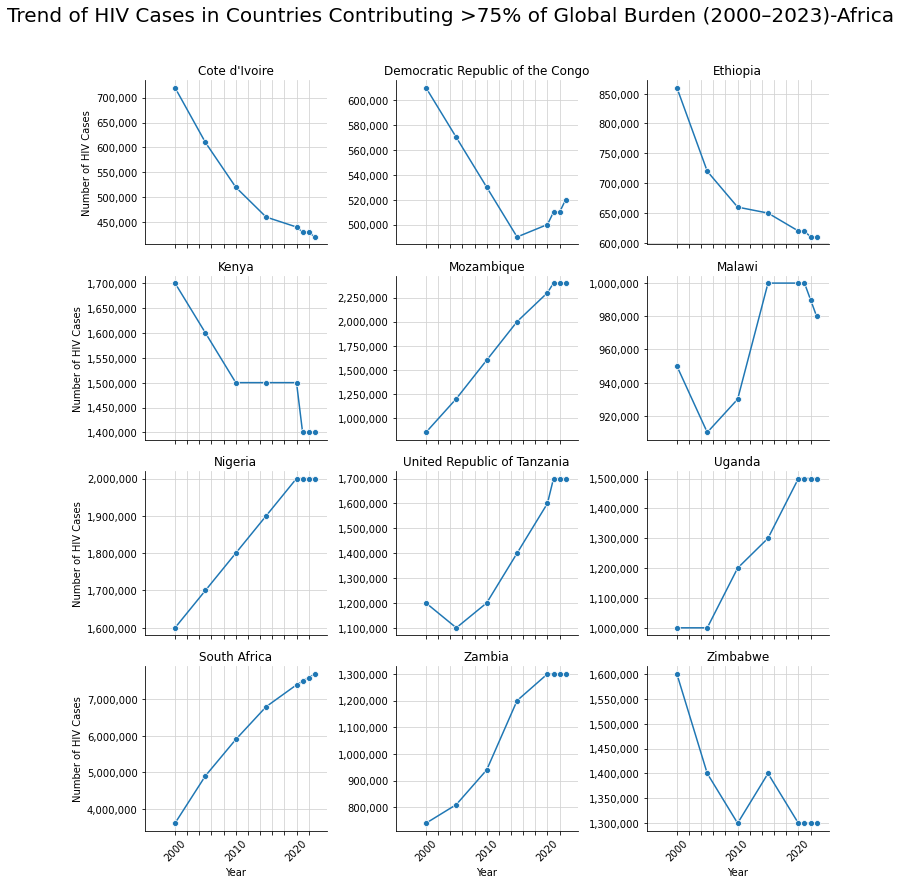

In [51]:
g = sns.FacetGrid(
    trend_data_Africa,
    col='Location',
    col_wrap=3, 
    height=3,    
    aspect=1.2,  
    sharey=False  
)
# Plot lines for each country
g.map(sns.lineplot, 'Period', 'ApproxNoOfInfections', marker='o')
g.set_titles('{col_name}', size=12)  # Use country name as subplot title
g.set_axis_labels('Year', 'Number of HIV Cases')
g.set_xticklabels(rotation=45)
# Add grid and format y-axis
for ax in g.axes.flat:
    ax.grid(True, color='lightgray')
    ax.set_xticks(range(2000, 2024, 2))  # X-ticks every 2 years
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
# Adding main title
g.fig.suptitle('Trend of HIV Cases in Countries Contributing >75% of Global Burden (2000–2023)-Africa', y=1.02, fontsize=20)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

##### Explanation:
   Africa bears a disproportionate burden of the global HIV/AIDS epidemic, contributing 85% of the 75% global prevalence. South Africa has the highest number of people living with HIV, followed closely by Mozambique, Nigeria, Kenya, and Tanzania. While several countries—including Kenya, Ethiopia, Zimbabwe, and the Democratic Republic of Congo—experienced a steady decline in new infections up to around 2013, many others, such as South Africa, Zimbabwe, Tanzania, and Nigeria, continue to report rising cases. This pattern suggests progress has been uneven, with gains in some regions and  setbacks in others.African countries still need to strengthen their public health infrastructure,scale up access to ART treatment,combat stigma and enhance cross border collaboration for the fight against HIV and AIDS.

#### 2.South-East Asia

In [52]:
mask=trend_data["ParentLocation"]=="South-East Asia"
trend_data_SE_Asia=trend_data[mask]
trend_data_SE_Asia

,ParentLocation,SpatialDimValueCode,Location,Period,ApproxNoOfInfections
1272,South-East Asia,IND,India,2023,2500000.0
1320,South-East Asia,THA,Thailand,2023,580000.0
1321,South-East Asia,THA,Thailand,2022,580000.0
1322,South-East Asia,THA,Thailand,2021,590000.0
1323,South-East Asia,THA,Thailand,2020,590000.0
1324,South-East Asia,THA,Thailand,2015,640000.0
1325,South-East Asia,THA,Thailand,2010,720000.0
1326,South-East Asia,THA,Thailand,2005,810000.0
1327,South-East Asia,THA,Thailand,2000,920000.0


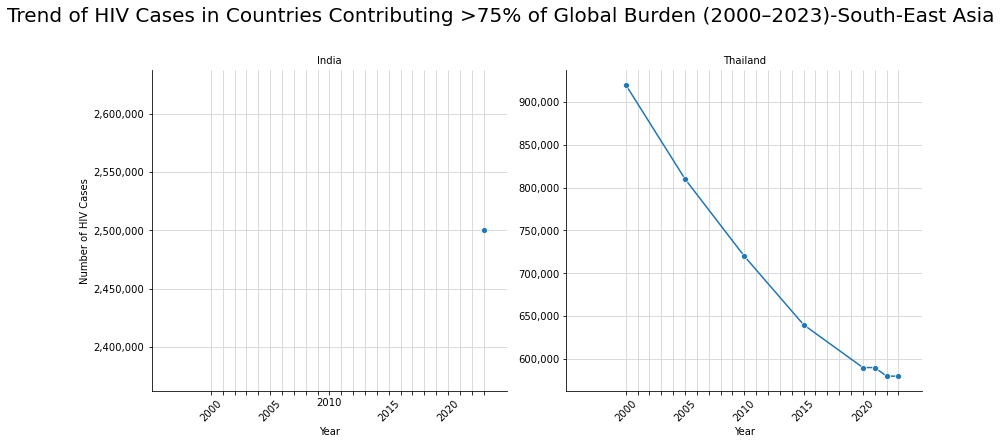

In [53]:
g = sns.FacetGrid(
    trend_data_SE_Asia,
    col='Location',
    col_wrap=2, 
    height=6,    
    aspect=1,  
    sharey=False  
)
# Plot lines for each country
g.map(sns.lineplot, 'Period', 'ApproxNoOfInfections', marker='o')
g.set_titles('{col_name}', size=10)  # Use country name as subplot title
g.set_axis_labels('Year', 'Number of HIV Cases')
g.set_xticklabels(rotation=45)
# Add grid and format y-axis
for ax in g.axes.flat:
    ax.grid(True, color='lightgray')
    ax.set_xticks(range(2000, 2024,1)) 
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
# Adding main title
g.fig.suptitle('Trend of HIV Cases in Countries Contributing >75% of Global Burden (2000–2023)-South-East Asia', y=1.02, fontsize=20)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

##### Explanation:
India leads in the number of infections in South East Asia at about 2.5 million followed by Thailand.Thailand has however witnessed a sharp decline in the number of infections from about 950 thousand cases to a low of about 550 thousand people living with HIV and AIDS in 2023.India's prevalence can be attributed to its huge population of about 1.44 bilion people.The decline in the number of infections in Thailand can be attributted to  a combination of early intervention, innovative prevention strategies, and sustained political commitment.

#### 3.Americas

In [54]:
mask=trend_data["ParentLocation"]=="Americas"
trend_data_Americas=trend_data[mask]
trend_data_Americas

,ParentLocation,SpatialDimValueCode,Location,Period,ApproxNoOfInfections
416,Americas,BRA,Brazil,2023,1000000.0
417,Americas,BRA,Brazil,2022,970000.0
418,Americas,BRA,Brazil,2021,940000.0
419,Americas,BRA,Brazil,2020,910000.0
420,Americas,BRA,Brazil,2015,770000.0
421,Americas,BRA,Brazil,2010,640000.0
422,Americas,BRA,Brazil,2005,490000.0
423,Americas,BRA,Brazil,2000,350000.0


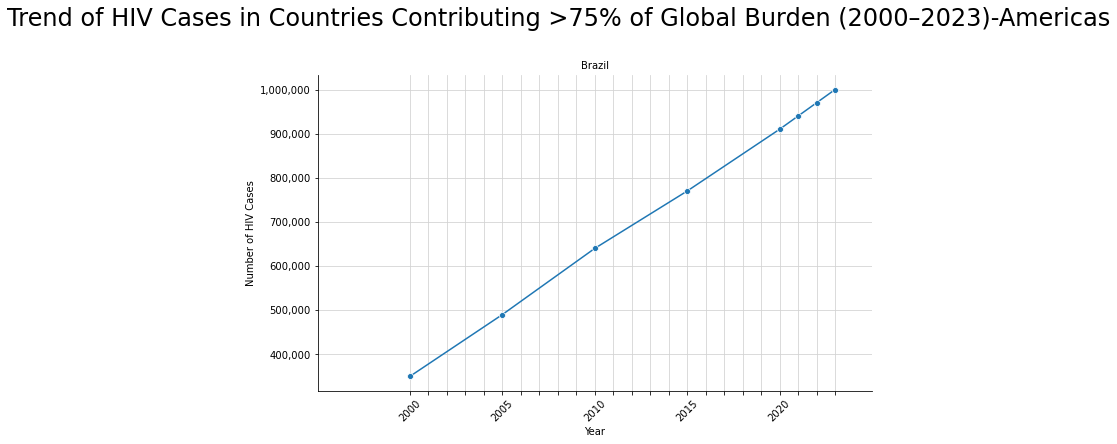

In [55]:
g = sns.FacetGrid(
    trend_data_Americas,
    col='Location',
    col_wrap=1, 
    height=6,    
    aspect=1.5,  
    sharey=False  
)
# Plot lines for each country
g.map(sns.lineplot, 'Period', 'ApproxNoOfInfections', marker='o')
g.set_titles('{col_name}', size=10)  # Use country name as subplot title
g.set_axis_labels('Year', 'Number of HIV Cases')
g.set_xticklabels(rotation=45)
# Add grid and format y-axis
for ax in g.axes.flat:
    ax.grid(True, color='lightgray')
    ax.set_xticks(range(2000, 2024, 1))  # X-ticks every 2 years
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
# Adding main title
g.fig.suptitle('Trend of HIV Cases in Countries Contributing >75% of Global Burden (2000–2023)-Americas', y=1.02, fontsize=24)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

##### Explanation,
In the Americas region,Brazil leads with about one million people living with HIV and AIDS.Brazil over the years has seen a surge in its population.some other factors that may have contributed to this include, disproportionate impact on Young Men Who Have Sex with Men (YMSM),regional disparities and rising incidence in the Amazon region,cultural and social factors affecting prevention efforts,stigma and discrimination hindering access to services among others.

#### 4.2.2.Relationship between people living with HIV and multidimensional poverty.

In [56]:
poverty_data.head()

,Region,Country_Code,Country,Year,Survey_Name,Survey_Year,Coverage,Welfare_type,Survey_Comparability,Poverty_Rate,Education_Attainment,Education_Enrollment,Electricity_Access,Sanitation_Access,Drinking_Water_Access,PovertyHeadCountRatio
0,SSA,AGO,Angola,2018,IDREA,2018,N,c,2,31.122005,29.753423,27.443060,52.639532,53.637516,32.106507,47.203606
1,ECA,ALB,Albania,2012,HBS,2018,N,c,1,0.048107,0.192380,3.045111,0.060250,6.579772,9.594966,0.293161
2,LAC,ARG,Argentina,2010,EPHC-S2,2021,U,i,3,0.894218,1.085320,0.731351,0.000000,0.257453,0.364048,0.906573
3,ECA,ARM,Armenia,2010,ILCS,2021,N,c,1,0.523521,0.000000,1.793004,0.000000,0.397725,0.660082,0.523521
4,EAP,AUS,Australia,2010,SIH-LIS,2018,N,I,3,0.516880,1.711880,3.045111,0.000000,0.000000,2.421072,2.215770


In [57]:
HIV_data.head()

,ParentLocation,SpatialDimValueCode,Location,Period,ApproxNoOfInfections
0,Africa,AGO,Angola,2023,320000.0
1,Africa,AGO,Angola,2022,320000.0
2,Africa,AGO,Angola,2021,320000.0
3,Africa,AGO,Angola,2020,320000.0
4,Africa,AGO,Angola,2015,300000.0


In [58]:
#merging the two datasets
HIV_data_renamed = HIV_data.rename(columns={
    'SpatialDimValueCode': 'Country_Code',
    'Location': 'Country',
    'Period': 'Year'
})
df_merged = pd.merge(poverty_data, HIV_data_renamed, on=['Country_Code', 'Year'])
df_merged.head(3)

,Region,Country_Code,Country_x,Year,Survey_Name,Survey_Year,Coverage,Welfare_type,Survey_Comparability,Poverty_Rate,Education_Attainment,Education_Enrollment,Electricity_Access,Sanitation_Access,Drinking_Water_Access,PovertyHeadCountRatio,ParentLocation,Country_y,ApproxNoOfInfections
0,LAC,ARG,Argentina,2010,EPHC-S2,2021,U,i,3,0.894218,1.08532,0.731351,0.0,0.257453,0.364048,0.906573,Americas,Argentina,92000.0
1,ECA,ARM,Armenia,2010,ILCS,2021,N,c,1,0.523521,0.00000,1.793004,0.0,0.397725,0.660082,0.523521,Europe,Armenia,1800.0
2,EAP,AUS,Australia,2010,SIH-LIS,2018,N,I,3,0.516880,1.71188,3.045111,0.0,0.000000,2.421072,2.215770,Western Pacific,Australia,20000.0


In [59]:
#converting year to string format
df_merged["Year"] =df_merged['Year'].astype("str")

In [60]:
df_merged.isna().info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 39 entries, 0 to 38
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Region                 39 non-null     bool 
 1   Country_Code           39 non-null     bool 
 2   Country_x              39 non-null     bool 
 3   Year                   39 non-null     bool 
 4   Survey_Name            39 non-null     bool 
 5   Survey_Year            39 non-null     bool 
 6   Coverage               39 non-null     bool 
 7   Welfare_type           39 non-null     bool 
 8   Survey_Comparability   39 non-null     bool 
 9   Poverty_Rate           39 non-null     bool 
 10  Education_Attainment   39 non-null     bool 
 11  Education_Enrollment   39 non-null     bool 
 12  Electricity_Access     39 non-null     bool 
 13  Sanitation_Access      39 non-null     bool 
 14  Drinking_Water_Access  39 non-null     bool 
 15  PovertyHeadCountRatio  39 non-null     boo

There are no null values in the dataset. 

#### DISCLAIMER: This analysis comprises of 39 countries representing only 20% of global count.

In [61]:
print(f"The countries observed are: {df_merged['Country_x'].to_list()}")

The countries observed are: ['Argentina', 'Armenia', 'Australia', 'Benin', 'Bangladesh', 'Belarus', "Cote d'Ivoire", 'Colombia', 'Costa Rica', 'Germany', 'Dominican Republic', 'Ecuador', 'Egypt, Arab Republic of', 'Georgia', 'Guinea-Bissau', 'Honduras', 'Croatia', 'Israel', 'Kazakhstan', 'Kenya', 'Kyrgyz Republic', 'Moldova', 'Mexico', 'Malawi', 'Nepal', 'Pakistan', 'Panama', 'Peru', 'Paraguay', 'Romania', 'El Salvador', 'Serbia', 'Suriname', 'Tunisia', 'Ukraine', 'Uruguay', 'Uzbekistan', 'Viet Nam', 'Zambia']


#### Visualizing the relationship between HIV and Multidimensional poverty

In [62]:
# Calculate correlation
correlation = df_merged["PovertyHeadCountRatio"].corr(df_merged["ApproxNoOfInfections"])
print("Correlation:", correlation)

Correlation: 0.7318889595556669


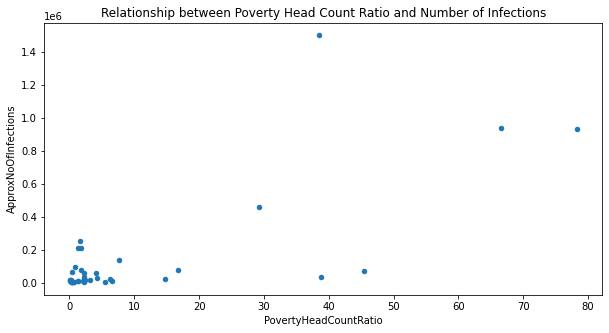

In [63]:
fig,ax=plt.subplots(figsize=(10,5))
df_merged.plot(kind="scatter",x="PovertyHeadCountRatio",y="ApproxNoOfInfections",ax=ax);
ax.set_title("Relationship between Poverty Head Count Ratio and Number of Infections");

##### Explanation:

The relationship between Poverty Head Count Ratio and and number of infections seem to be linear.This is supported by the correlation coefficient of 0.73 which suggests a strong linear relationship.As the Poverty Head Count Ratio increases or decreases,the number of HIV also either increases or decreases.This does not however mean that an increase or decrease  in Poverty Head Count Ratio causes the same in the number of HIV/AIDS infections.

**N/B:CORRELATION IS NOT CAUSALITY**

##### 4.2.3.Relationship between Education Attainment and Poverty Head Count Ratio.

In [64]:
#countries with the highest education attainment and the poverty headcount ratio
df_merged[["Country_x","Education_Attainment","Electricity_Access","Poverty_Rate","PovertyHeadCountRatio"]].sort_values(by="Education_Attainment").head()

,Country_x,Education_Attainment,Electricity_Access,Poverty_Rate,PovertyHeadCountRatio
1,Armenia,0.000000,0.000000,0.523521,0.523521
36,Uzbekistan,0.000000,0.127470,2.253092,2.253092
5,Belarus,0.000000,0.134809,0.000000,3.157514
18,Kazakhstan,0.003963,0.000000,0.015141,0.019104
20,Kyrgyz Republic,0.007727,0.000000,0.715779,0.715779


From the observed countries,Armenia,Uzbekistan,Belarus,Kazakhstan, and Kyrgyz Republic are the top five countries with the highest Education Attainment with almost 100% of the population considered literate as per the World Health Organization literacy Standards.This finding is corroborated by the World Bank's Data that classifies the literacy rates for these countries as approximately 99.8%,99%,99.9%,99.8 and 99.6 respectively.The high literacy rates in Armenia, Uzbekistan, Belarus, Kazakhstan, and the Kyrgyz Republic stem from a robust Soviet-era education legacy, compulsory and free schooling, strong cultural valuing of education, government investment, low poverty barriers, effective post-independence reforms, stable governance, and high enrollment rates. These factors collectively ensure that nearly 100% of the population achieves literacy, aligning with UNESCO standards.

In [65]:
#countries with the lowest education attainment and the poverty headcount ratio
df_merged[["Country_x","Education_Attainment","Electricity_Access","Poverty_Rate","PovertyHeadCountRatio"]].sort_values(by="Education_Attainment").tail()

,Country_x,Education_Attainment,Electricity_Access,Poverty_Rate,PovertyHeadCountRatio
25,Pakistan,21.092634,9.321731,4.932448,16.667987
30,El Salvador,25.155506,1.674593,3.586186,6.253187
6,Cote d'Ivoire,44.493997,9.264950,9.733193,29.177094
3,Benin,49.023893,34.818304,12.723279,45.443240
23,Malawi,54.329389,88.757396,70.060599,78.252000


Text(0.5, 1.0, 'Relationship between Education Attainment and Poverty Head Count Ratio')

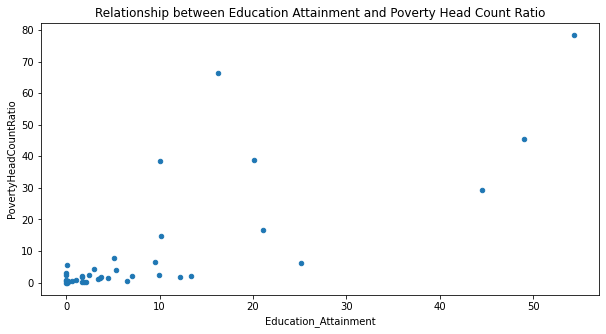

In [66]:
fig,ax=plt.subplots(figsize=(10,5))
df_merged.plot(kind="scatter",x="Education_Attainment",y="PovertyHeadCountRatio",ax=ax)
plt.title("Relationship between Education Attainment and Poverty Head Count Ratio")

Malawi leads in the number of illeteracy with more than half of its population considered illeterate as per the UNESCO standards according to the analyzed data.Benin follows at 49%,Cote d'ivore at 44%,El Salvador at 25% and finally Pakistan at 21%.This differs with the UNESCO's latest report placing Malawi's illiteracy rate at 35%,Benin at 57.6%,Cote d'Ivore at 52.8%,El Salvador at 18% and Pakistan at 37.2%.The discrepancy could be due to the use of old data.

**Reasons for High Illiteracy:**

Shared Factors: Poverty, limited school access, gender disparities, conflict/instability, underfunded education, and cultural barriers.

Specific Issues: Malawi’s rural poverty, Benin’s economic disruptions, Côte d'Ivoire’s conflict legacy, El Salvador’s gang violence, and Pakistan’s cultural and regional challenges could be a reason for the high illiteracy rates.

##### 4.2.4 Relationship between Electricity Access and Poverty Head Count Ratio

Text(0.5, 1.0, 'Relationship between Electricity Access and Poverty Head Count Ratio')

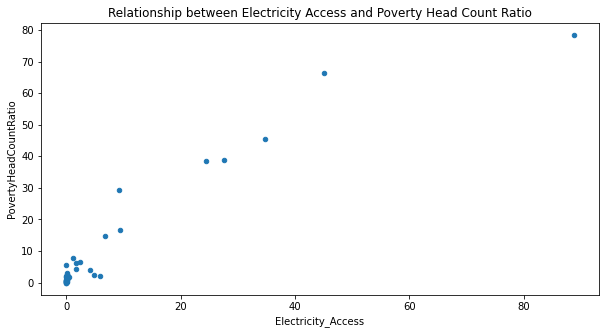

In [67]:
fig,ax=plt.subplots(figsize=(10,5))
df_merged.plot(kind="scatter",x="Electricity_Access",y="PovertyHeadCountRatio",ax=ax)
plt.title("Relationship between Electricity Access and Poverty Head Count Ratio")

In [68]:
#top  5 contries with the highest electricity access
df_merged[["Country_x","Electricity_Access","PovertyHeadCountRatio"]].sort_values(by="Electricity_Access").head()

,Country_x,Electricity_Access,PovertyHeadCountRatio
0,Argentina,0.0,0.906573
34,Ukraine,0.0,1.674372
20,Kyrgyz Republic,0.0,0.715779
18,Kazakhstan,0.0,0.019104
17,Israel,0.0,0.347770


Kazakhstan leads with 100% Electricity Access and with the lowest Poverty Head Count Ratio followed closely by Israel,Kyrgyz Republic,Argentina and Ukraine closes the top five countries.- 

**Reasons for the high Electricity Access**

Kazakhstan: Oil and gas wealth, Soviet-era grids, and minimal poverty (~0.02%) drive 100% access and top ranking.

Israel: High-income economy ($54,000 GDP per capita), advanced grids, and low poverty (0.35%) ensure universal access.

Kyrgyz Republic: Soviet-era hydropower and low poverty (~0.72%) via remittances and aid support ~99.8% access.

Argentina: Urbanization (92%) and subsidies achieve 100% access, with low international poverty (0.91%).

Ukraine: Soviet-era infrastructure maintains 99.9% access despite war, with low poverty (1.67%).



In [69]:
#top  5 contries with the lowest electricity access
df_merged[["Country_x","Electricity_Access","PovertyHeadCountRatio"]].sort_values(by="Electricity_Access").tail()

,Country_x,Electricity_Access,PovertyHeadCountRatio
19,Kenya,24.500306,38.490102
14,Guinea-Bissau,27.570510,38.730049
3,Benin,34.818304,45.443240
38,Zambia,45.135146,66.506058
23,Malawi,88.757396,78.252000


Malawi is one of the least electrified countries globally(only 11% of the country electrified) with extremely low electricity access majorly in rural areas.Zambia follows with 45% of its population lacking electricity followed by Benin,Guinea-Bissau and lastly Kenya.In conclusion, the countries with the lowest electricity access;Kenya, Guinea-Bissau, Benin, Zambia, and Malawi face a combination of high poverty rates, underdeveloped infrastructure, limited investment, and political or regulatory challenges. These factors create a cycle where lack of resources hinders electrification efforts, and the absence of electricity, in turn, limits economic development and poverty reduction. Addressing these systemic issues requires coordinated efforts in governance, investment, and rural development to break the cycle and expand access to electricity. 

In [70]:
#countries with the lowest poverty head count ratio
df_merged[["Country_x","PovertyHeadCountRatio"]].sort_values(by="PovertyHeadCountRatio").head()

,Country_x,PovertyHeadCountRatio
29,Romania,0.012860
18,Kazakhstan,0.019104
35,Uruguay,0.148147
31,Serbia,0.233548
21,Moldova,0.239448


In [71]:
#countries with the highest poverty head count ratio
df_merged[["Country_x","PovertyHeadCountRatio"]].sort_values(by="PovertyHeadCountRatio").tail()

,Country_x,PovertyHeadCountRatio
19,Kenya,38.490102
14,Guinea-Bissau,38.730049
3,Benin,45.443240
38,Zambia,66.506058
23,Malawi,78.252000


 Nations like Romania and Kazakhstan exhibit extremely low poverty headcount ratios (around 1–2%), reflecting strong economic conditions, effective social policies, and relatively high standards of living. In contrast, countries such as Malawi, Zambia, and Benin report alarmingly high poverty rates, exceeding 45% and reaching up to 78%. These disparities underscore significant global inequalities, often rooted in differences in infrastructure, governance, conflict, and economic development. Addressing such gaps requires targeted international cooperation and sustainable development strategies.

### 5.0 Feature Extraction and Modelling

Regression Analysis will help us understand the important features that contribute  to the Poverty Head Count Ratio.

In [72]:
#checking for cardinality
df_merged.nunique()

Region                    6
Country_Code             39
Country_x                39
Year                      3
Survey_Name              31
Survey_Year               5
Coverage                  2
Welfare_type              3
Survey_Comparability      7
Poverty_Rate             37
Education_Attainment     37
Education_Enrollment     34
Electricity_Access       29
Sanitation_Access        35
Drinking_Water_Access    35
PovertyHeadCountRatio    39
ParentLocation            6
Country_y                39
ApproxNoOfInfections     36
dtype: int64

In [73]:
#dropping the columns the high cardinality columns
df_merged.drop(columns=["Region","Sanitation_Access","Country_Code","Survey_Name","Survey_Year","Country_y","ParentLocation"],inplace=True)

The target is PovertyHeadCountRatio column.The rest of the features are predictors.Let us examine to see the correlation between the features and drop columns that are highly correlated to prevent multicollinearity.

In [74]:
df_merged.corr().drop(columns=["PovertyHeadCountRatio"])

,Survey_Comparability,Poverty_Rate,Education_Attainment,Education_Enrollment,Electricity_Access,Drinking_Water_Access,ApproxNoOfInfections
Survey_Comparability,1.000000,0.048567,-0.185130,-0.041230,-0.071993,0.007672,0.053195
Poverty_Rate,0.048567,1.000000,0.586407,0.379814,0.926975,0.676090,0.799411
Education_Attainment,-0.185130,0.586407,1.000000,0.653639,0.751335,0.512112,0.402762
Education_Enrollment,-0.041230,0.379814,0.653639,1.000000,0.428490,0.579885,0.160575
Electricity_Access,-0.071993,0.926975,0.751335,0.428490,1.000000,0.603029,0.667719
Drinking_Water_Access,0.007672,0.676090,0.512112,0.579885,0.603029,1.000000,0.732359
PovertyHeadCountRatio,-0.024198,0.944650,0.776515,0.604794,0.950283,0.761442,0.731889
ApproxNoOfInfections,0.053195,0.799411,0.402762,0.160575,0.667719,0.732359,1.000000


In [75]:
# Select the features for VIF calculation
features = df_merged.drop(columns=["PovertyHeadCountRatio"]).select_dtypes(include="number").columns.to_list()
X = df_merged[features]
# Add a constant term for VIF calculation
X = X.assign(const=1)
# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

                 Feature        VIF
0   Survey_Comparability   1.126876
1           Poverty_Rate  18.975353
2   Education_Attainment   5.118436
3   Education_Enrollment   3.654931
4     Electricity_Access  18.267171
5  Drinking_Water_Access   4.297364
6   ApproxNoOfInfections   6.122896
7                  const   5.271562


In [76]:
df_merged["Electricity_Access"].corr(df_merged["Poverty_Rate"])

0.9269746418496689

There is a high positive correlation between the two predictors.They are however two distinct features that may contribute independently to the target.The columns are retained for further analysis.

In [77]:
#splitting the data to into features and the target
features=df_merged.drop(columns=["PovertyHeadCountRatio"],axis=1)#features
target=df_merged["PovertyHeadCountRatio"]#target

In [78]:
#selecting categorical columns
categorical_features=features.select_dtypes(include="object").drop(columns=["Year","Country_x"]).columns.to_list()
categorical_features

['Coverage', 'Welfare_type']

In [79]:
#numerical features
numerical_features=features.select_dtypes(exclude="object").columns.to_list()
numerical_features

['Survey_Comparability',
 'Poverty_Rate',
 'Education_Attainment',
 'Education_Enrollment',
 'Electricity_Access',
 'Drinking_Water_Access',
 'ApproxNoOfInfections']

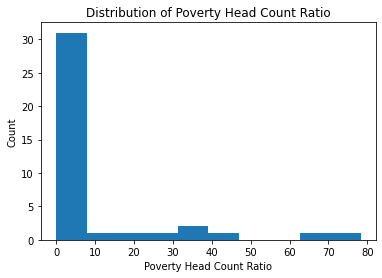

In [80]:
#plotting the distribution of the target
target.plot(kind="hist");
plt.xlabel("Poverty Head Count Ratio")
plt.ylabel("Count")
plt.title("Distribution of Poverty Head Count Ratio");

In [81]:
#checking for the mean
target.mean()

10.066826694730048

In [82]:
#checking for the median
target.median()

2.17114090919494

In [83]:
#checking for the most frequent values
target.mode()[0]

0.012860287097282699

Our target variable "PovertyHeadCountRatio",is right sweked as viewed on the above plot.Majority of the countries have a poverty Head Count Ratio of about 1.3  signifying low poverty,however some countries have very high poverty head count leading to the imbalance.This can be solved by log transforming the target.

In [84]:
#log transforming the target
target_log_transformed=np.log1p(target)
#double log transforming to achieve a better normalization
target_log_transformed1=np.log1p(target_log_transformed)
log_target = pd.Series(target_log_transformed1, name='Log_Target', index=target.index)

<AxesSubplot:ylabel='Frequency'>

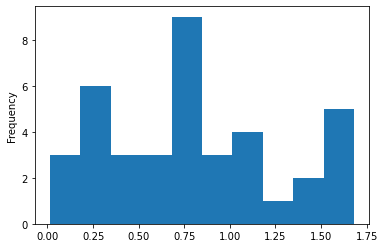

In [85]:
log_target.plot(kind="hist")

Log transforming the target has slightly normalized the distribution. 

In [87]:
#creating a preprocessing pipeline 
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse=False), categorical_features)
    ]
)
X_preprocessed = preprocessor.fit_transform(features[numerical_features + categorical_features])
# Get feature names after preprocessing
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names(categorical_features)
feature_names = numerical_features + list(cat_feature_names)
X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=feature_names, index=features.index)
# Combine with Country_x, Year, and log-transformed target
data_for_model = pd.concat([X_preprocessed_df, df_merged[['Country_x', 'Year']], log_target], axis=1)

In [90]:
#fitting the model
fixed_effects = " + ".join(feature_names)
formula = f"Log_Target ~ {fixed_effects}"
model = smf.mixedlm(formula, data=data_for_model, groups=data_for_model['Country_x'])
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
================================================================
Model:                MixedLM   Dependent Variable:   Log_Target
No. Observations:     39        Method:               REML      
No. Groups:           39        Scale:                0.0413    
Min. group size:      1         Log-Likelihood:       -17.4730  
Max. group size:      1         Converged:            Yes       
Mean group size:      1.0                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.696    0.172  4.060 0.000  0.360  1.033
Survey_Comparability   0.036    0.056  0.646 0.518 -0.074  0.147
Poverty_Rate           0.339    0.066  5.164 0.000  0.210  0.467
Education_Attainment   0.241    0.096  2.504 0.012  0.052  0.430
Education_Enrollment   0.098    0.080  1.226 0.220 -0.059  0.254
Electricity_Access    -0.265    0.101 -2.621 0.009 -0.463 -0.067
Drinking_Water_Access  0.079    0.091  0.874 0.382 -0.099  0.257
ApproxNoOfInfections  -0.001    0.084 -0.010 0.992 -0.165  0.163
Coverage_U            -0.111    0.302 -0.367 0.713 -0.704  0.482
Welfare_type_c         0.068    0.182  0.373 0.709 -0.289  0.425
Welfare_type_i         0.178    0.203  0.879 0.380 -0.219  0.575
Group Var              0.041                                    
================================================================

"""

#### Findings:

##### Significant Predictors:

##### Significant Predictors:

**Monetary_Poverty p = 0.000**: A 1-unit increase in standardized monetary poverty is associated with a 33.9% decrease in the poverty headcount ratio, indicating a strong positive relationship. This suggests that monetary poverty is a key driver of multidimensional poverty.

**Education_Attainment p = 0.012**: A 1-unit increase in standardized education attainment is associated with a 24.1% decrease  in poverty.


**Electricity_Access p = 0.009**: A 1-unit increase in standardized electricity access is associated with a 26.5% decrease in poverty, aligning with expectations—better access to electricity reduces multidimensional poverty by improving living conditions.The significant negative effect of Electricity_Access suggests that improving electricity infrastructure is a high-impact strategy for reducing poverty. Access to electricity can enhance education, healthcare, and economic opportunities, thereby alleviating multidimensional poverty.



##### Non-Significant Predictors:

**ApproxNoOfInfections p = 0.992**: The coefficient (-0.001) is negligible, indicating no meaningful effect of HIV prevalence on multidimensional poverty in this model.

**Education_Enrollment p = 0.220**: A 1-unit increase is associated with a 9.8% increase in poverty, but this is not statistically significant.


### 6.0 Conclusion
A mixed-effects model in Python (statsmodels) was used to predict log-transformed multidimensional poverty from HIV cases and other socioeconomic factors. With 39 countries, the model included random intercepts for country to address clustering. Monetary poverty (coef = 0.339, p < 0.001),education attainment (coef = 0.241, p = 0.012) and electricity access (coef = -0.265, p = 0.009) were linked to lower poverty.HIV prevalence showed no significant impact (coef = -0.001, p = 0.992).Improving electricity access and education attainment could be key to reducing poverty.

### 7.0 Recommendation

**Larger Sample Size:**
The dataset has only 39 observations (1 per country), which is small for a mixed-effects model, especially with random effects.  Increasing the sample size, especially with multiple observations per country, would improve the reliability of the estimates and allow for more complex random effects.

In [91]:
#countries with the highest education attainment and the poverty headcount ratio
df_merged[["Country_x","Education_Attainment","PovertyHeadCountRatio"]].sort_values(by="Education_Attainment").head(30)

,Country_x,Education_Attainment,PovertyHeadCountRatio
1,Armenia,0.000000,0.523521
36,Uzbekistan,0.000000,2.253092
5,Belarus,0.000000,3.157514
18,Kazakhstan,0.003963,0.019104
20,Kyrgyz Republic,0.007727,0.715779
13,Georgia,0.024344,5.493653
29,Romania,0.086624,0.012860
21,Moldova,0.133399,0.239448
16,Croatia,0.145387,0.453452
17,Israel,0.560530,0.347770


In [94]:
df_merged["Electricity_Access"].corr(df_merged["PovertyHeadCountRatio"])

0.9502832807903154

<AxesSubplot:xlabel='Electricity_Access', ylabel='PovertyHeadCountRatio'>

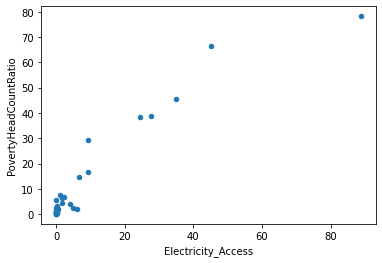

In [95]:
df_merged.plot(kind="scatter",x="Electricity_Access",y="PovertyHeadCountRatio")

## Task 2

### 1.0 Overview
Data on the under-five mortality rate and neonatal mortality rate for the African region,downloaded from the UN Inter-agency Group for Child Mortality Estimation has been provide.

### 2.0 Objectives

1.To Filter data for the eight countries belonging to the East African Community.

2.To Visualize the latest estimate of each indicator at the country level using shapefiles.

3.To Show the average trends in the mortality rates over time.

4.To identify the countries with the highest under-five mortality rates in East Africa and the highest neonatal mortality


### 3.0 Data Understanding 

In [96]:
#loading the datasets
neonatal_mortality_rate=pd.read_csv("neonatal_mortality_rate.csv")
under_five_mortality_rate=pd.read_csv("under_five mortality rate.csv")
DS_dataset=pd.read_csv("dataset_datascience.csv")

#### 3.0.1 neonatal_mortality_rate

In [97]:
#checking for the first five rows
neonatal_mortality_rate.head()

,REF_AREA,Geographic area,INDICATOR,Indicator,SEX,Sex,WEALTH_QUINTILE,Wealth Quintile,SERIES_NAME,Series Name,...,DEFINITION,INTERVAL,SERIES_METHOD,Series Method,LOWER_BOUND,UPPER_BOUND,STATUS,YEAR_TO_ACHIEVE,MODEL,Model Used
0,UNSDG_SUBSAHARANAFRICA,Sub-Saharan Africa,MRM0,Neonatal mortality rate,_T,Total,_T,Total,UN_IGME,UN IGME estimate,...,NaN,1,NaN,NaN,43.782426,47.617352,NaN,NaN,NaN,NaN
1,UNSDG_SUBSAHARANAFRICA,Sub-Saharan Africa,MRM0,Neonatal mortality rate,_T,Total,_T,Total,UN_IGME,UN IGME estimate,...,NaN,1,NaN,NaN,43.413053,47.180684,NaN,NaN,NaN,NaN
2,UNSDG_SUBSAHARANAFRICA,Sub-Saharan Africa,MRM0,Neonatal mortality rate,_T,Total,_T,Total,UN_IGME,UN IGME estimate,...,NaN,1,NaN,NaN,43.084346,46.798108,NaN,NaN,NaN,NaN
3,UNSDG_SUBSAHARANAFRICA,Sub-Saharan Africa,MRM0,Neonatal mortality rate,_T,Total,_T,Total,UN_IGME,UN IGME estimate,...,NaN,1,NaN,NaN,42.653348,46.304417,NaN,NaN,NaN,NaN
4,UNSDG_SUBSAHARANAFRICA,Sub-Saharan Africa,MRM0,Neonatal mortality rate,_T,Total,_T,Total,UN_IGME,UN IGME estimate,...,NaN,1,NaN,NaN,42.378536,45.948982,NaN,NaN,NaN,NaN


In [98]:
#checking for the number of columns and rows
neonatal_mortality_rate.shape
print(f"The data frame contains {neonatal_mortality_rate.shape[0]} rows and {neonatal_mortality_rate.shape[1]} columns")

The data frame contains 34 rows and 44 columns


In [99]:
#checking for general information about the dataset
neonatal_mortality_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   REF_AREA                34 non-null     object 
 1   Geographic area         34 non-null     object 
 2   INDICATOR               34 non-null     object 
 3   Indicator               34 non-null     object 
 4   SEX                     34 non-null     object 
 5   Sex                     34 non-null     object 
 6   WEALTH_QUINTILE         34 non-null     object 
 7   Wealth Quintile         34 non-null     object 
 8   SERIES_NAME             34 non-null     object 
 9   Series Name             34 non-null     object 
 10  SERIES_YEAR             34 non-null     int64  
 11  Series Year             34 non-null     int64  
 12  REGIONAL_GROUP          0 non-null      float64
 13  Regional group          0 non-null      float64
 14  TIME_PERIOD             34 non-null     obje

The data types contained are 25 float values, 4 integer values and 15 non numeric values.There are missing values in the dataset.

In [100]:
#checking for statistical summary of the dataset
neonatal_mortality_rate.describe()

,SERIES_YEAR,Series Year,REGIONAL_GROUP,Regional group,OBS_VALUE,COUNTRY_NOTES,CONNECTION,DEATH_CATEGORY,CATEGORY,SERIES_CATEGORY,...,DEFINITION,INTERVAL,SERIES_METHOD,Series Method,LOWER_BOUND,UPPER_BOUND,STATUS,YEAR_TO_ACHIEVE,MODEL,Model Used
count,34.0,34.0,0.0,0.0,34.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,34.0,0.0,0.0,34.000000,34.000000,0.0,0.0,0.0,0.0
mean,2023.0,2023.0,NaN,NaN,35.542027,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,33.829772,37.911037,NaN,NaN,NaN,NaN
std,0.0,0.0,NaN,NaN,6.217636,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,6.425001,5.566387,NaN,NaN,NaN,NaN
min,2023.0,2023.0,NaN,NaN,26.410295,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,23.594381,31.899664,NaN,NaN,NaN,NaN
25%,2023.0,2023.0,NaN,NaN,30.235887,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,28.510075,32.797596,NaN,NaN,NaN,NaN
50%,2023.0,2023.0,NaN,NaN,34.466132,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,33.139034,36.021846,NaN,NaN,NaN,NaN
75%,2023.0,2023.0,NaN,NaN,41.376171,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,39.858744,43.124946,NaN,NaN,NaN,NaN
max,2023.0,2023.0,NaN,NaN,45.540454,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,43.782426,47.617352,NaN,NaN,NaN,NaN


In [101]:
#checking for duplicate values
neonatal_mortality_rate.duplicated().sum()

0

There are no duplicated rows or columns in the dataset.

##### 3.0.2 Under Five Mortality Rate

In [102]:
#checking for the first three columns
under_five_mortality_rate.head(3)

,REF_AREA,Geographic area,INDICATOR,Indicator,SEX,Sex,WEALTH_QUINTILE,Wealth Quintile,SERIES_NAME,Series Name,...,DEFINITION,INTERVAL,SERIES_METHOD,Series Method,LOWER_BOUND,UPPER_BOUND,STATUS,YEAR_TO_ACHIEVE,MODEL,Model Used
0,UNSDG_SUBSAHARANAFRICA,Sub-Saharan Africa,MRY0T4,Under-five mortality rate,_T,Total,_T,Total,UN_IGME,UN IGME estimate,...,NaN,1,NaN,NaN,198.675695,209.928512,NaN,NaN,NaN,NaN
1,UNSDG_SUBSAHARANAFRICA,Sub-Saharan Africa,MRY0T4,Under-five mortality rate,_T,Total,_T,Total,UN_IGME,UN IGME estimate,...,NaN,1,NaN,NaN,195.249935,205.879194,NaN,NaN,NaN,NaN
2,UNSDG_SUBSAHARANAFRICA,Sub-Saharan Africa,MRY0T4,Under-five mortality rate,_T,Total,_T,Total,UN_IGME,UN IGME estimate,...,NaN,1,NaN,NaN,192.162302,202.345691,NaN,NaN,NaN,NaN


In [103]:
#checking for the shape
under_five_mortality_rate.shape
print(f"The data frame contains {under_five_mortality_rate.shape[0]} rows and {under_five_mortality_rate.shape[1]} columns")

The data frame contains 44 rows and 44 columns


In [104]:
#checking for general information about the dataset
under_five_mortality_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   REF_AREA                44 non-null     object 
 1   Geographic area         44 non-null     object 
 2   INDICATOR               44 non-null     object 
 3   Indicator               44 non-null     object 
 4   SEX                     44 non-null     object 
 5   Sex                     44 non-null     object 
 6   WEALTH_QUINTILE         44 non-null     object 
 7   Wealth Quintile         44 non-null     object 
 8   SERIES_NAME             44 non-null     object 
 9   Series Name             44 non-null     object 
 10  SERIES_YEAR             44 non-null     int64  
 11  Series Year             44 non-null     int64  
 12  REGIONAL_GROUP          0 non-null      float64
 13  Regional group          0 non-null      float64
 14  TIME_PERIOD             44 non-null     obje

The data types contained are 25 float values, 4 integer values and 15 non numeric values.There are missing values in the dataset.

In [105]:
#checking for statistical summary
under_five_mortality_rate.describe()

,SERIES_YEAR,Series Year,REGIONAL_GROUP,Regional group,OBS_VALUE,COUNTRY_NOTES,CONNECTION,DEATH_CATEGORY,CATEGORY,SERIES_CATEGORY,...,DEFINITION,INTERVAL,SERIES_METHOD,Series Method,LOWER_BOUND,UPPER_BOUND,STATUS,YEAR_TO_ACHIEVE,MODEL,Model Used
count,44.0,44.0,0.0,0.0,44.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,44.0,0.0,0.0,44.000000,44.000000,0.0,0.0,0.0,0.0
mean,2023.0,2023.0,NaN,NaN,140.282310,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,136.187313,145.921463,NaN,NaN,NaN,NaN
std,0.0,0.0,NaN,NaN,45.934157,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,46.289481,44.581894,NaN,NaN,NaN,NaN
min,2023.0,2023.0,NaN,NaN,68.819285,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,62.200671,82.200122,NaN,NaN,NaN,NaN
25%,2023.0,2023.0,NaN,NaN,94.934204,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,91.105741,99.990189,NaN,NaN,NaN,NaN
50%,2023.0,2023.0,NaN,NaN,143.944688,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,141.023338,147.469182,NaN,NaN,NaN,NaN
75%,2023.0,2023.0,NaN,NaN,182.696216,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,178.918181,187.006908,NaN,NaN,NaN,NaN
max,2023.0,2023.0,NaN,NaN,204.178538,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,199.321189,209.928512,NaN,NaN,NaN,NaN


In [106]:
#checking for duplicates.
under_five_mortality_rate.duplicated().sum()

0

No duplicated values

#### 3.0.3 Other Dataset

In [107]:
DS_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129564 entries, 0 to 129563
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   REF_AREA                129564 non-null  object 
 1   Geographic area         129564 non-null  object 
 2   Regional group          7138 non-null    object 
 3   Indicator               129564 non-null  object 
 4   Sex                     129564 non-null  object 
 5   Wealth Quintile         129564 non-null  object 
 6   Series Name             129564 non-null  object 
 7   Series Year             129564 non-null  object 
 8   Reference Date          129564 non-null  float64
 9   Observation Value       129528 non-null  float64
 10  Lower Bound             73949 non-null   float64
 11  Upper Bound             73949 non-null   float64
 12  Standard Error          30793 non-null   float64
 13  Country notes           4710 non-null    object 
 14  Observation Status  

This dataset has 23 variables and 129564 observations.There are missing values in the dataset.

### 4.0 Data Cleaning and Exploration

Since the two datasets are similar ,they are merged before cleaning.

In [108]:
data_merged=pd.concat([neonatal_mortality_rate,under_five_mortality_rate],axis=0)
data_merged.head(3)

,REF_AREA,Geographic area,INDICATOR,Indicator,SEX,Sex,WEALTH_QUINTILE,Wealth Quintile,SERIES_NAME,Series Name,...,DEFINITION,INTERVAL,SERIES_METHOD,Series Method,LOWER_BOUND,UPPER_BOUND,STATUS,YEAR_TO_ACHIEVE,MODEL,Model Used
0,UNSDG_SUBSAHARANAFRICA,Sub-Saharan Africa,MRM0,Neonatal mortality rate,_T,Total,_T,Total,UN_IGME,UN IGME estimate,...,NaN,1,NaN,NaN,43.782426,47.617352,NaN,NaN,NaN,NaN
1,UNSDG_SUBSAHARANAFRICA,Sub-Saharan Africa,MRM0,Neonatal mortality rate,_T,Total,_T,Total,UN_IGME,UN IGME estimate,...,NaN,1,NaN,NaN,43.413053,47.180684,NaN,NaN,NaN,NaN
2,UNSDG_SUBSAHARANAFRICA,Sub-Saharan Africa,MRM0,Neonatal mortality rate,_T,Total,_T,Total,UN_IGME,UN IGME estimate,...,NaN,1,NaN,NaN,43.084346,46.798108,NaN,NaN,NaN,NaN


In [109]:
data_merged.shape
print(f"The resulting dataframe consists of {data_merged.shape[0]} rows and {data_merged.shape[1]} columns")

The resulting dataframe consists of 78 rows and 44 columns


In [110]:
#checking for percentage missing values
percentage_missing=data_merged.isna().mean()*100
percentage_missing

REF_AREA                    0.0
Geographic area             0.0
INDICATOR                   0.0
Indicator                   0.0
SEX                         0.0
Sex                         0.0
WEALTH_QUINTILE             0.0
Wealth Quintile             0.0
SERIES_NAME                 0.0
Series Name                 0.0
SERIES_YEAR                 0.0
Series Year                 0.0
REGIONAL_GROUP            100.0
Regional group            100.0
TIME_PERIOD                 0.0
OBS_VALUE                   0.0
COUNTRY_NOTES             100.0
CONNECTION                100.0
DEATH_CATEGORY            100.0
CATEGORY                  100.0
OBS_STATUS                  0.0
Observation Status          0.0
UNIT_MEASURE                0.0
Unit of measure             0.0
SERIES_CATEGORY           100.0
Series Category           100.0
SERIES_TYPE               100.0
Series Type               100.0
STD_ERR                   100.0
REF_DATE                    0.0
AGE_GROUP_OF_WOMEN        100.0
Age Grou

In [111]:
#columns with 100% missing values
columns_to_drop=percentage_missing[percentage_missing==100].index.to_list()
columns_to_drop

['REGIONAL_GROUP',
 'Regional group',
 'COUNTRY_NOTES',
 'CONNECTION',
 'DEATH_CATEGORY',
 'CATEGORY',
 'SERIES_CATEGORY',
 'Series Category',
 'SERIES_TYPE',
 'Series Type',
 'STD_ERR',
 'AGE_GROUP_OF_WOMEN',
 'Age Group of Women',
 'TIME_SINCE_FIRST_BIRTH',
 'Time Since First Birth',
 'DEFINITION',
 'SERIES_METHOD',
 'Series Method',
 'STATUS',
 'YEAR_TO_ACHIEVE',
 'MODEL',
 'Model Used']

In [112]:
data_merged.drop(columns=columns_to_drop,inplace=True)

In [113]:
#checking for cardinality
data_merged.nunique()

REF_AREA               1
Geographic area        1
INDICATOR              2
Indicator              2
SEX                    1
Sex                    1
WEALTH_QUINTILE        1
Wealth Quintile        1
SERIES_NAME            1
Series Name            1
SERIES_YEAR            1
Series Year            1
TIME_PERIOD           44
OBS_VALUE             78
OBS_STATUS             1
Observation Status     1
UNIT_MEASURE           1
Unit of measure        1
REF_DATE              44
INTERVAL               1
LOWER_BOUND           78
UPPER_BOUND           78
dtype: int64

In [114]:
data_merged["Geographic area"].value_counts()

Sub-Saharan Africa    78
Name: Geographic area, dtype: int64

The data_merged dataset will not be used as it only contains Sub Saharan Africa data while the required data for analysis should have East Africa Community countries.

In [115]:
#ccleaning the DS_dataset
#checking for missing values
percent_missing=DS_dataset.isna().mean()*100
percent_missing

REF_AREA                    0.000000
Geographic area             0.000000
Regional group             94.490754
Indicator                   0.000000
Sex                         0.000000
Wealth Quintile             0.000000
Series Name                 0.000000
Series Year                 0.000000
Reference Date              0.000000
Observation Value           0.027785
Lower Bound                42.924732
Upper Bound                42.924732
Standard Error             76.233367
Country notes              96.364731
Observation Status          0.000000
Unit of measure             0.000000
Series Type                57.075268
Series Category            57.075268
Series Method              57.075268
Age Group of Women         95.141397
Time Since First Birth     99.413417
Definition                100.000000
Interval                    8.331790
dtype: float64

In [116]:
#dropping columns with more than 30% missing values
cols_to_drop=percent_missing[percent_missing>30].index.to_list()
cols_to_drop

['Regional group',
 'Lower Bound',
 'Upper Bound',
 'Standard Error',
 'Country notes',
 'Series Type',
 'Series Category',
 'Series Method',
 'Age Group of Women',
 'Time Since First Birth',
 'Definition']

In [117]:
DS_dataset.drop(columns=cols_to_drop,inplace=True)

In [118]:
#dropping rows with missing values
DS_dataset.dropna(inplace=True)
DS_dataset.isna().sum().sum()

0

There are no missing values in the dataset.

In [119]:
#checking for cardinality
DS_dataset.nunique()

REF_AREA                 243
Geographic area          235
Indicator                  2
Sex                        3
Wealth Quintile            6
Series Name              675
Series Year              121
Reference Date           441
Observation Value     112862
Observation Status         3
Unit of measure            1
Interval                  17
dtype: int64

In [120]:
#dropping the unit measure column
DS_dataset=DS_dataset.drop(columns=["Unit of measure","REF_AREA"])

#### 4.0.1 selecting countries in East Africa Community

In [121]:
#Countries in the EAC
EAC_countries = [
    "Burundi",
    "Democratic Republic of the Congo",
    "Kenya",
    "Rwanda",
    "South Sudan",
    "United Republic of Tanzania",
    "Uganda",
    "Somalia"
]

In [122]:
mask=DS_dataset["Geographic area"].isin(EAC_countries)
data_EAC=DS_dataset[mask].reset_index(drop=True)

In [123]:
#viewing the first five columns of the data
data_EAC["Geographic area"].value_counts()

Rwanda                              823
Kenya                               819
Uganda                              814
United Republic of Tanzania         807
Burundi                             501
Democratic Republic of the Congo    460
South Sudan                         442
Somalia                             360
Name: Geographic area, dtype: int64

In [124]:
#viewing the last 5 rows of the dataset
data_EAC.tail()

,Geographic area,Indicator,Sex,Wealth Quintile,Series Name,Series Year,Reference Date,Observation Value,Observation Status,Interval
5021,Uganda,Under-five mortality rate,Total,Total,UN IGME estimate,2023,2019.5,45.307572,Normal value,1.0
5022,Uganda,Under-five mortality rate,Total,Total,UN IGME estimate,2023,2020.5,43.509117,Normal value,1.0
5023,Uganda,Under-five mortality rate,Total,Total,UN IGME estimate,2023,2021.5,41.786456,Normal value,1.0
5024,Uganda,Under-five mortality rate,Total,Total,UN IGME estimate,2023,2022.5,40.493282,Normal value,1.0
5025,Uganda,Under-five mortality rate,Total,Total,UN IGME estimate,2023,2023.5,38.807676,Normal value,1.0


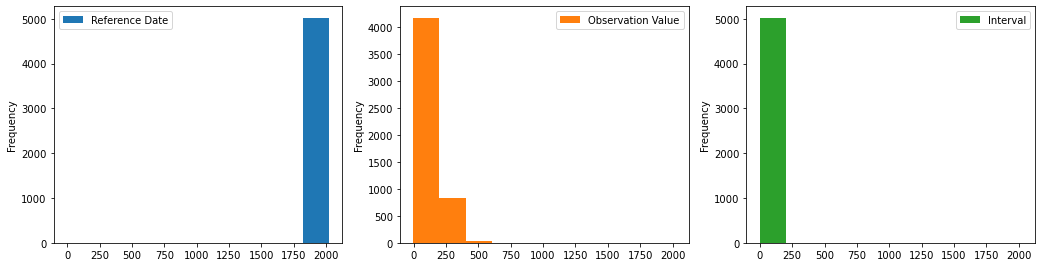

In [125]:
#checking the distribution
data_EAC.plot(kind="hist", subplots=True, layout=(4, 5), figsize=(30, 20));

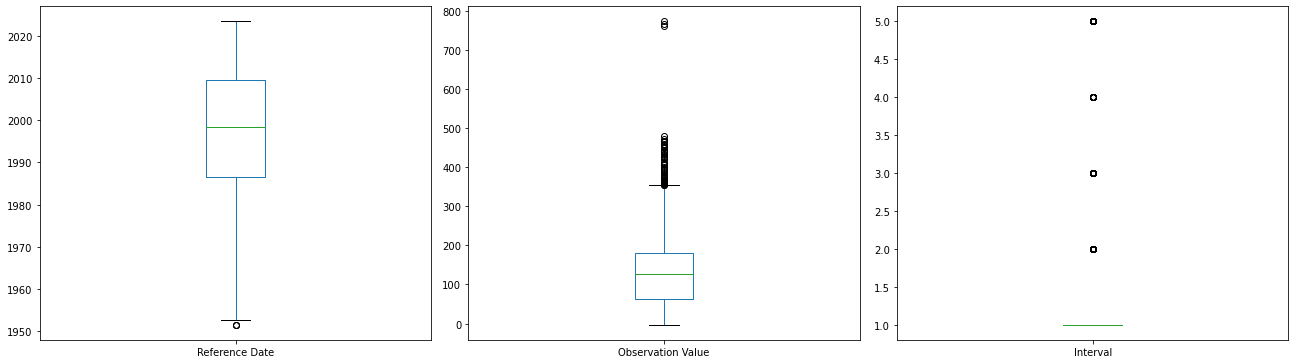

In [126]:
data_EAC.plot(kind='box', subplots=True, layout=(4, 5), figsize=(30, 20), sharex=False, sharey=False)
plt.tight_layout()
plt.show()


The Reference Date is fairly normally distributed with few outlier values on the lower end.The other two are right skewed.Log transformation will be used to normalize the skewed distributions.

In [127]:
data_EAC["Sex"].value_counts()

Total     3654
Male       686
Female     686
Name: Sex, dtype: int64

In [128]:
#filtering to have the total estimates rather than by gender or wealth quantile
data_EAC = data_EAC[(data_EAC["Sex"] == "Total") & (data_EAC["Wealth Quintile"] == "Total")]

In [129]:
#dropping unnecessary columns
data_EAC = data_EAC[["Geographic area", "Indicator", "Reference Date", "Observation Value"]]

In [130]:
#Aggregating data by the geographical area,and reference date.
df_pivot = data_EAC.pivot_table(
    index=["Geographic area", "Reference Date"],
    columns="Indicator",
    values="Observation Value",
    aggfunc="mean"
).reset_index().dropna()
df_pivot

Indicator,Geographic area,Reference Date,Neonatal mortality rate,Under-five mortality rate
0,Burundi,1964.5,49.244938,241.498679
2,Burundi,1965.5,49.900299,234.336850
3,Burundi,1966.5,49.952441,245.351663
4,Burundi,1967.5,49.872070,247.289779
5,Burundi,1968.5,49.937962,249.004284
...,...,...,...,...
629,United Republic of Tanzania,2019.5,23.339783,45.996349
630,United Republic of Tanzania,2020.5,22.209006,41.017503
631,United Republic of Tanzania,2021.5,21.644546,42.167631
632,United Republic of Tanzania,2022.5,21.095299,40.482164


In [131]:
#latest_estimate=latest_year
#selecting the latest year
latest_estimate=df_pivot["Reference Date"].max()
print(f"The latest estimate year is {latest_estimate}")

The latest estimate year is 2023.5


In [132]:
#picking only the year 2023.5 from the data
mask=df_pivot["Reference Date"]==2023.5
latest_data=df_pivot[mask]

In [133]:
#checking for the first five values of the dataframe
latest_data

Indicator,Geographic area,Reference Date,Neonatal mortality rate,Under-five mortality rate
70,Burundi,2023.5,19.603026,49.207185
125,Democratic Republic of the Congo,2023.5,25.346972,73.189681
228,Kenya,2023.5,21.513320,39.902085
310,Rwanda,2023.5,18.126902,40.014641
352,Somalia,2023.5,34.904816,104.019175
425,South Sudan,2023.5,40.240552,98.728442
520,Uganda,2023.5,17.851216,38.807676
633,United Republic of Tanzania,2023.5,20.564352,38.857044


In [134]:
#stripping the reference date to only have the year
latest_data["Reference Date"]=latest_data["Reference Date"].astype(str)
latest_data["Reference Date"]=latest_data["Reference Date"].str.split(".",expand=True)[0]
#converting to datetime formart
latest_data["Reference Date"]=pd.to_datetime(latest_data["Reference Date"],format="%Y",errors="coerce").dt.year
latest_data["Reference Date"]

70     2023
125    2023
228    2023
310    2023
352    2023
425    2023
520    2023
633    2023
Name: Reference Date, dtype: int64

In [135]:
latest_data.reset_index(drop=True,inplace=True)

In [136]:
#renaming the columns
latest_data.rename(columns={"Geographic area":"Country",
                           "Reference Date":"Year"},inplace=True)

In [137]:
latest_data

Indicator,Country,Year,Neonatal mortality rate,Under-five mortality rate
0,Burundi,2023,19.603026,49.207185
1,Democratic Republic of the Congo,2023,25.346972,73.189681
2,Kenya,2023,21.513320,39.902085
3,Rwanda,2023,18.126902,40.014641
4,Somalia,2023,34.904816,104.019175
5,South Sudan,2023,40.240552,98.728442
6,Uganda,2023,17.851216,38.807676
7,United Republic of Tanzania,2023,20.564352,38.857044


In [138]:
#mapping the shapes to the countries
shapefile_paths = {
    "Burundi": "gadm41_BDI_0.shp",
    "Democratic Republic of the Congo": "gadm41_COD_0.shp",
    "Kenya": "gadm41_KEN_0.shp",
    "Rwanda": "gadm41_RWA_0.shp",
    "Somalia": "gadm41_SOM_0.shp",
    "South Sudan": "gadm41_SSD_0.shp",
    "United Republic of Tanzania": "gadm41_TZA_0.shp",
    "Uganda": "gadm41_UGA_0.shp"
}

In [139]:
# Load each shapefile and combine into a single GeoDataFrame
gdfs = []
for country, path in shapefile_paths.items():
    try:
        gdf_country = gpd.read_file(path)
        gdfs.append(gdf_country)
    except FileNotFoundError:
        print(f"Shapefile for {country} not found: {path}")
    except Exception as e:
        print(f"Error loading shapefile for {country}: {e}")

# Combine all GeoDataFrames
if gdfs:
    gdf_eac = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))
    print("Columns in combined GeoDataFrame:", gdf_eac.columns.tolist())
else:
    raise ValueError("No shapefiles were loaded successfully.")

# Standardize country names using the correct column
gdf_eac["COUNTRY"] = gdf_eac["COUNTRY"].replace({"Tanzania": "United Republic of Tanzania"})
print("Standardized country names in shapefile:", gdf_eac["COUNTRY"].unique())

Columns in combined GeoDataFrame: ['GID_0', 'COUNTRY', 'geometry']
Standardized country names in shapefile: ['Burundi' 'Democratic Republic of the Congo' 'Kenya' 'Rwanda' 'Somalia'
 'South Sudan' 'United Republic of Tanzania' 'Uganda']


In [140]:
#merging the latest data and the gfs
gdf_eac = gdf_eac.merge(latest_data, left_on="COUNTRY", right_on="Country")
gdf_eac

,GID_0,COUNTRY,geometry,Country,Year,Neonatal mortality rate,Under-five mortality rate
0,BDI,Burundi,"POLYGON ((30.04515 -4.25684, 30.04523 -4.25760...",Burundi,2023,19.603026,49.207185
1,COD,Democratic Republic of the Congo,"MULTIPOLYGON (((27.24913 -11.79462, 27.24780 -...",Democratic Republic of the Congo,2023,25.346972,73.189681
2,KEN,Kenya,"MULTIPOLYGON (((39.38014 -4.71792, 39.37986 -4...",Kenya,2023,21.513320,39.902085
3,RWA,Rwanda,"POLYGON ((29.71332 -2.81759, 29.71295 -2.81774...",Rwanda,2023,18.126902,40.014641
4,SOM,Somalia,"MULTIPOLYGON (((41.61347 -1.60930, 41.61319 -1...",Somalia,2023,34.904816,104.019175
5,SSD,South Sudan,"POLYGON ((29.79568 4.38430, 29.79645 4.38899, ...",South Sudan,2023,40.240552,98.728442
6,TZA,United Republic of Tanzania,"MULTIPOLYGON (((39.35587 -11.09155, 39.34812 -...",United Republic of Tanzania,2023,20.564352,38.857044
7,UGA,Uganda,"POLYGON ((29.91125 -1.47687, 29.91099 -1.47613...",Uganda,2023,17.851216,38.807676


In [141]:
#dropping the redundant column "COUNTRY" 
gdf_eac.drop(columns=["COUNTRY"],inplace=True)

In [142]:
gdf_eac["Country"] = gdf_eac["Country"].replace({
    "United Republic of Tanzania": "Tanzania",
    "Democratic Republic of the Congo": "DR Congo"
})

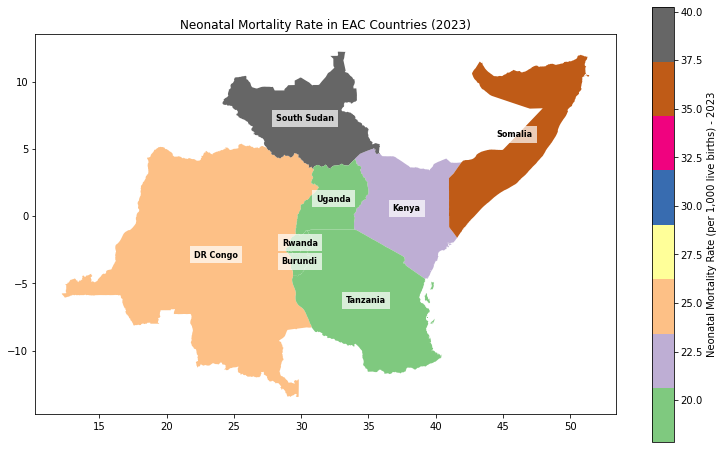

In [143]:
# Plotting NMR
fig, ax = plt.subplots(1, 1, figsize=(13, 8))
gdf_eac.plot(column="Neonatal mortality rate", ax=ax, legend=True, cmap="Accent",
             legend_kwds={"label": f"Neonatal Mortality Rate (per 1,000 live births) - {gdf_eac['Year'].iloc[0]}"})
for idx, row in gdf_eac.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(text=row['Country'], xy=(centroid.x, centroid.y), ha='center', va='center', fontsize=8, color='black', weight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.title(f"Neonatal Mortality Rate in EAC Countries ({gdf_eac['Year'].iloc[0]})")
plt.show()

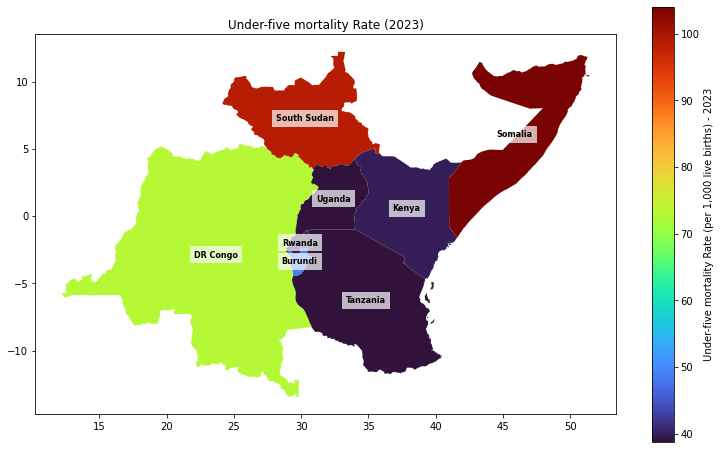

In [144]:
fig, ax = plt.subplots(1, 1, figsize=(13, 8))
gdf_eac.plot(column="Under-five mortality rate", ax=ax, legend=True, cmap="turbo",
             legend_kwds={"label": f"Under-five mortality Rate (per 1,000 live births) - {gdf_eac['Year'].iloc[0]}"})
for idx, row in gdf_eac.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(text=row['Country'], xy=(centroid.x, centroid.y), ha='center', va='center', fontsize=8, color='black', weight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.title(f"Under-five mortality Rate ({gdf_eac['Year'].iloc[0]})")
plt.show()

In [145]:
df = df_pivot.rename(columns={'Reference Date': 'Year', 'Geographic area': 'Country', 'Under-five mortality rate': 'U5MR', 'Neonatal mortality rate': 'NMR'})
df

Indicator,Country,Year,NMR,U5MR
0,Burundi,1964.5,49.244938,241.498679
2,Burundi,1965.5,49.900299,234.336850
3,Burundi,1966.5,49.952441,245.351663
4,Burundi,1967.5,49.872070,247.289779
5,Burundi,1968.5,49.937962,249.004284
...,...,...,...,...
629,United Republic of Tanzania,2019.5,23.339783,45.996349
630,United Republic of Tanzania,2020.5,22.209006,41.017503
631,United Republic of Tanzania,2021.5,21.644546,42.167631
632,United Republic of Tanzania,2022.5,21.095299,40.482164


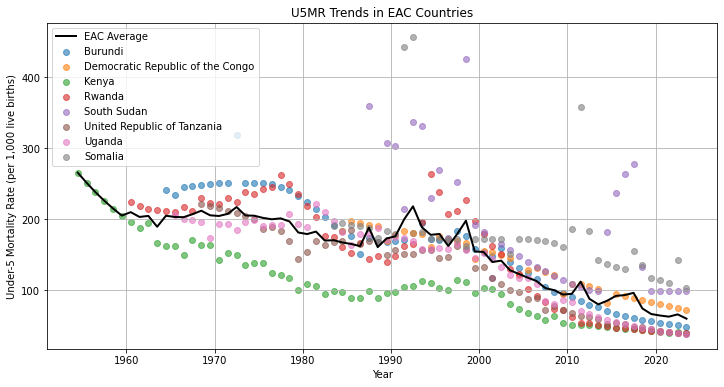

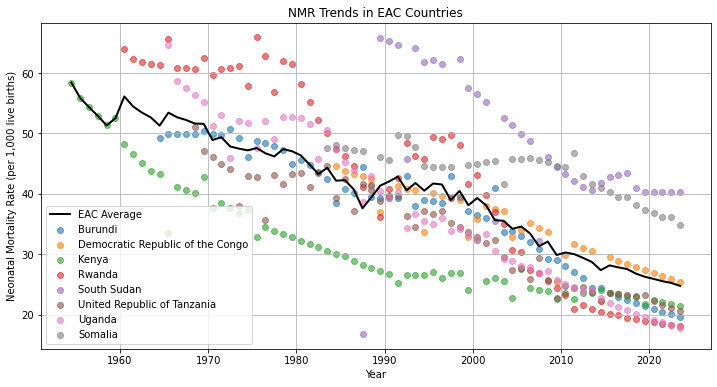

In [146]:
avg_trends = df.groupby('Year')[['U5MR', 'NMR']].mean().reset_index()

# Plot U5MR trends
plt.figure(figsize=(12,6))
plt.plot(avg_trends['Year'], avg_trends['U5MR'], label='EAC Average', color='black', linewidth=2)
for country in EAC_countries:
    country_data = df[df['Country'] == country]
    plt.scatter(country_data['Year'], country_data['U5MR'], label=country, alpha=0.6)
plt.xlabel('Year')
plt.ylabel('Under-5 Mortality Rate (per 1,000 live births)')
plt.title('U5MR Trends in EAC Countries')
plt.legend()
plt.grid(True)
plt.show()

# Plotting NMR trends
plt.figure(figsize=(12, 6))
plt.plot(avg_trends['Year'], avg_trends['NMR'], label='EAC Average', color='black', linewidth=2)
for country in EAC_countries:
    country_data = df[df['Country'] == country]
    plt.scatter(country_data['Year'], country_data['NMR'], label=country, alpha=0.6)
plt.xlabel('Year')
plt.ylabel('Neonatal Mortality Rate (per 1,000 live births)')
plt.title('NMR Trends in EAC Countries')
plt.legend()
plt.grid(True)
plt.show()

#### Explanation:
##### Under-five mortality rate
**Somalia**

In 2023, Somalia recorded the highest number of under-five deaths, though the mortality rate itself had declined to its lowest point in years. The highest rates were observed between 2005 and 2010, a period marked by extreme political instability, the absence of a central government, and the rise of Al-Shabaab, leaving health services reliant almost entirely on humanitarian aid. The entry of the Kenya Defence Forces in 2011 helped restore some stability, enabling better access to health services. Over the past five years, Somalia has experienced relative political calm, contributing to continued improvements. However, this decline in child mortality is also strongly linked to increased humanitarian support, including expanded vaccination coverage and improved nutrition programs.
